# Brazil E-Commerce (Olist) — In-Depth Data Analysis

## 1. Setup & Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# ── Global style ──────────────────────────────────────────────────────────────
PALETTE  = ["#2196F3", "#4CAF50", "#FF9800", "#9C27B0", "#F44336", "#00BCD4"]
BG       = "#F8F9FA"
TITLE_FS = 14
LABEL_FS = 11
TICK_FS  = 10
ANNOT_FS = 9

sns.set_theme(style="whitegrid", palette=PALETTE)
plt.rcParams.update({
    "figure.dpi":          130,
    "figure.facecolor":    BG,
    "axes.facecolor":      BG,
    "axes.titlesize":      TITLE_FS,
    "axes.titleweight":    "bold",
    "axes.titlepad":       12,
    "axes.labelsize":      LABEL_FS,
    "axes.labelpad":       8,
    "axes.spines.top":     False,
    "axes.spines.right":   False,
    "axes.grid":           True,
    "grid.color":          "#E0E0E0",
    "grid.linewidth":      0.8,
    "xtick.labelsize":     TICK_FS,
    "ytick.labelsize":     TICK_FS,
    "legend.fontsize":     TICK_FS,
    "figure.constrained_layout.use": True,
})

DATE_COLS = [
    "order_purchase_timestamp", "order_approved_at",
    "order_delivered_carrier_date", "order_delivered_customer_date",
    "order_estimated_delivery_date", "shipping_limit_date",
    "review_creation_date", "review_answer_timestamp"
]

df = pd.read_csv("main_dataset_clean.csv", parse_dates=DATE_COLS)
print("Shape:", df.shape)
df.head(3)


Shape: (106581, 45)


,order_id,order_item_id,order_status,delivery_date_missing_flag,timestamp_sequence_flag,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,...,shipping_limit_date,payment_type,payment_installments,payment_methods_count,payment_total_value,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,00010242fe8c5a6d1ba2dd792cb16214,1,delivered,0,0,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,...,2017-09-19 09:45:35,credit_card,2.0,1.0,72.19,5.0,NaN,"Perfeito, produto entregue antes do combinado.",2017-09-21 00:00:00,2017-09-22 10:57:03
1,00018f77f2f0320c557190d7a144bdd3,1,delivered,0,0,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,...,2017-05-03 11:05:13,credit_card,3.0,1.0,259.83,4.0,NaN,NaN,2017-05-13 00:00:00,2017-05-15 11:34:13
2,000229ec398224ef6ca0657da4fc703e,1,delivered,0,0,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,...,2018-01-18 14:48:30,credit_card,5.0,1.0,216.87,5.0,NaN,Chegou antes do prazo previsto e o produto sur...,2018-01-23 00:00:00,2018-01-23 16:06:31


## 2. Dataset Overview

In [2]:
total_items = len(df)
unique_orders = df['order_id'].nunique()
unique_customers = df['customer_unique_id'].nunique()
unique_products = df['product_id'].nunique()
unique_sellers = df['seller_id'].nunique()
unique_categories = df['product_category_name_english'].nunique()
date_min = df['order_purchase_timestamp'].min()
date_max = df['order_purchase_timestamp'].max()
total_revenue = df['price'].sum()
total_freight = df['freight_value'].sum()

print('=== Dataset Overview ===')
print(f'Total items (rows)  : {total_items:,}')
print(f'Unique orders       : {unique_orders:,}')
print(f'Unique customers    : {unique_customers:,}')
print(f'Unique products     : {unique_products:,}')
print(f'Unique sellers      : {unique_sellers:,}')
print(f'Unique categories   : {unique_categories:,}')
print(f'Date range          : {date_min.date()} to {date_max.date()}')
print(f'Total revenue       : R$ {total_revenue:,.2f}')
print(f'Total freight       : R$ {total_freight:,.2f}')

null_counts = df.isnull().sum()
null_pct = (null_counts / len(df) * 100).round(2)
null_df = pd.DataFrame({'null_count': null_counts, 'null_pct': null_pct})
null_df = null_df[null_df['null_count'] > 0].sort_values('null_count', ascending=False)
print('\n=== Null Value Summary ===')
print(null_df.to_string())

=== Dataset Overview ===
Total items (rows)  : 106,581
Unique orders       : 93,369
Unique customers    : 90,443
Unique products     : 31,919
Unique sellers      : 3,060
Unique categories   : 72
Date range          : 2016-09-04 to 2018-09-03
Total revenue       : R$ 12,862,961.28
Total freight       : R$ 2,129,812.62

=== Null Value Summary ===
                               null_count  null_pct
review_comment_title                93925     88.13
review_comment_message              61754     57.94
order_delivered_customer_date        2315      2.17
product_name_length                  1521      1.43
product_photos_qty                   1521      1.43
product_description_length           1521      1.43
order_delivered_carrier_date         1127      1.06
review_creation_date                  900      0.84
review_answer_timestamp               900      0.84
review_score                          900      0.84
customer_lng                          296      0.28
customer_lat                 

## 3. Order Status Analysis

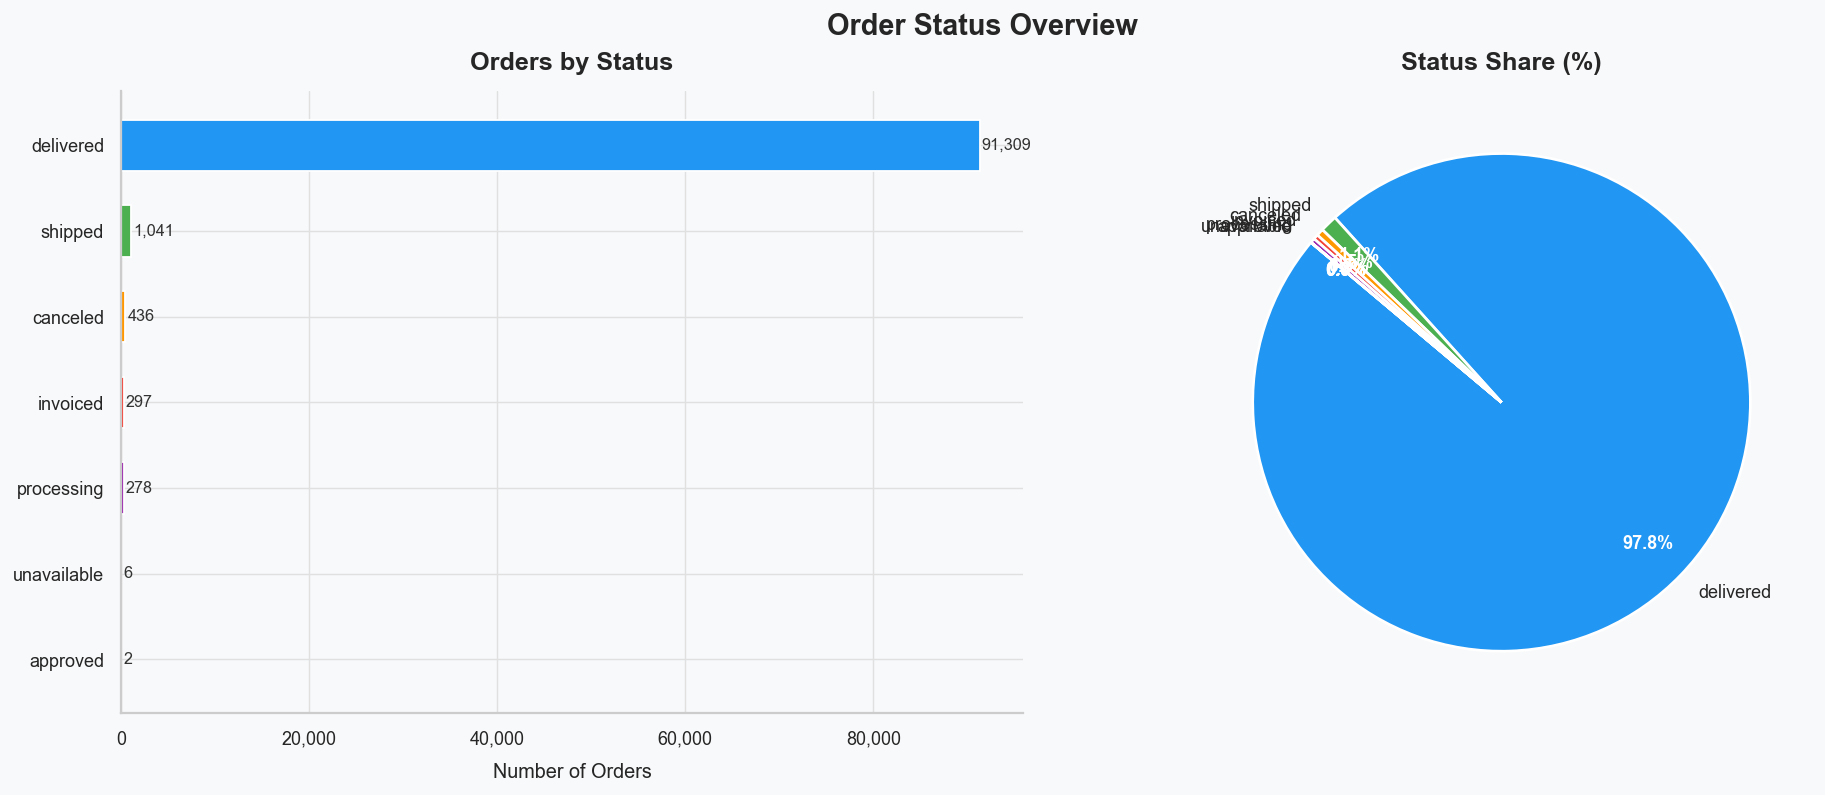

In [3]:
orders_df     = df.drop_duplicates("order_id")[["order_id", "order_status"]]
status_counts = orders_df["order_status"].value_counts()
PIE_COLORS    = ["#2196F3","#4CAF50","#FF9800","#F44336","#9C27B0","#00BCD4","#795548"]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Order Status Overview", fontsize=16, fontweight="bold")

# Bar
bars = axes[0].barh(status_counts.index, status_counts.values,
                    color=PIE_COLORS[:len(status_counts)], edgecolor="white", height=0.6)
axes[0].set_title("Orders by Status")
axes[0].set_xlabel("Number of Orders")
axes[0].invert_yaxis()
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for bar in bars:
    w = bar.get_width()
    axes[0].text(w + 200, bar.get_y() + bar.get_height()/2,
                 f"{int(w):,}", va="center", fontsize=ANNOT_FS, color="#333333")

# Pie
wedges, texts, autotexts = axes[1].pie(
    status_counts.values, labels=status_counts.index,
    autopct="%1.1f%%", startangle=140,
    colors=PIE_COLORS[:len(status_counts)],
    wedgeprops=dict(edgecolor="white", linewidth=1.5),
    pctdistance=0.82
)
for t in autotexts:
    t.set_fontsize(10); t.set_color("white"); t.set_fontweight("bold")
axes[1].set_title("Status Share (%)")

plt.show()


## 4. Revenue & Sales Trends Over Time

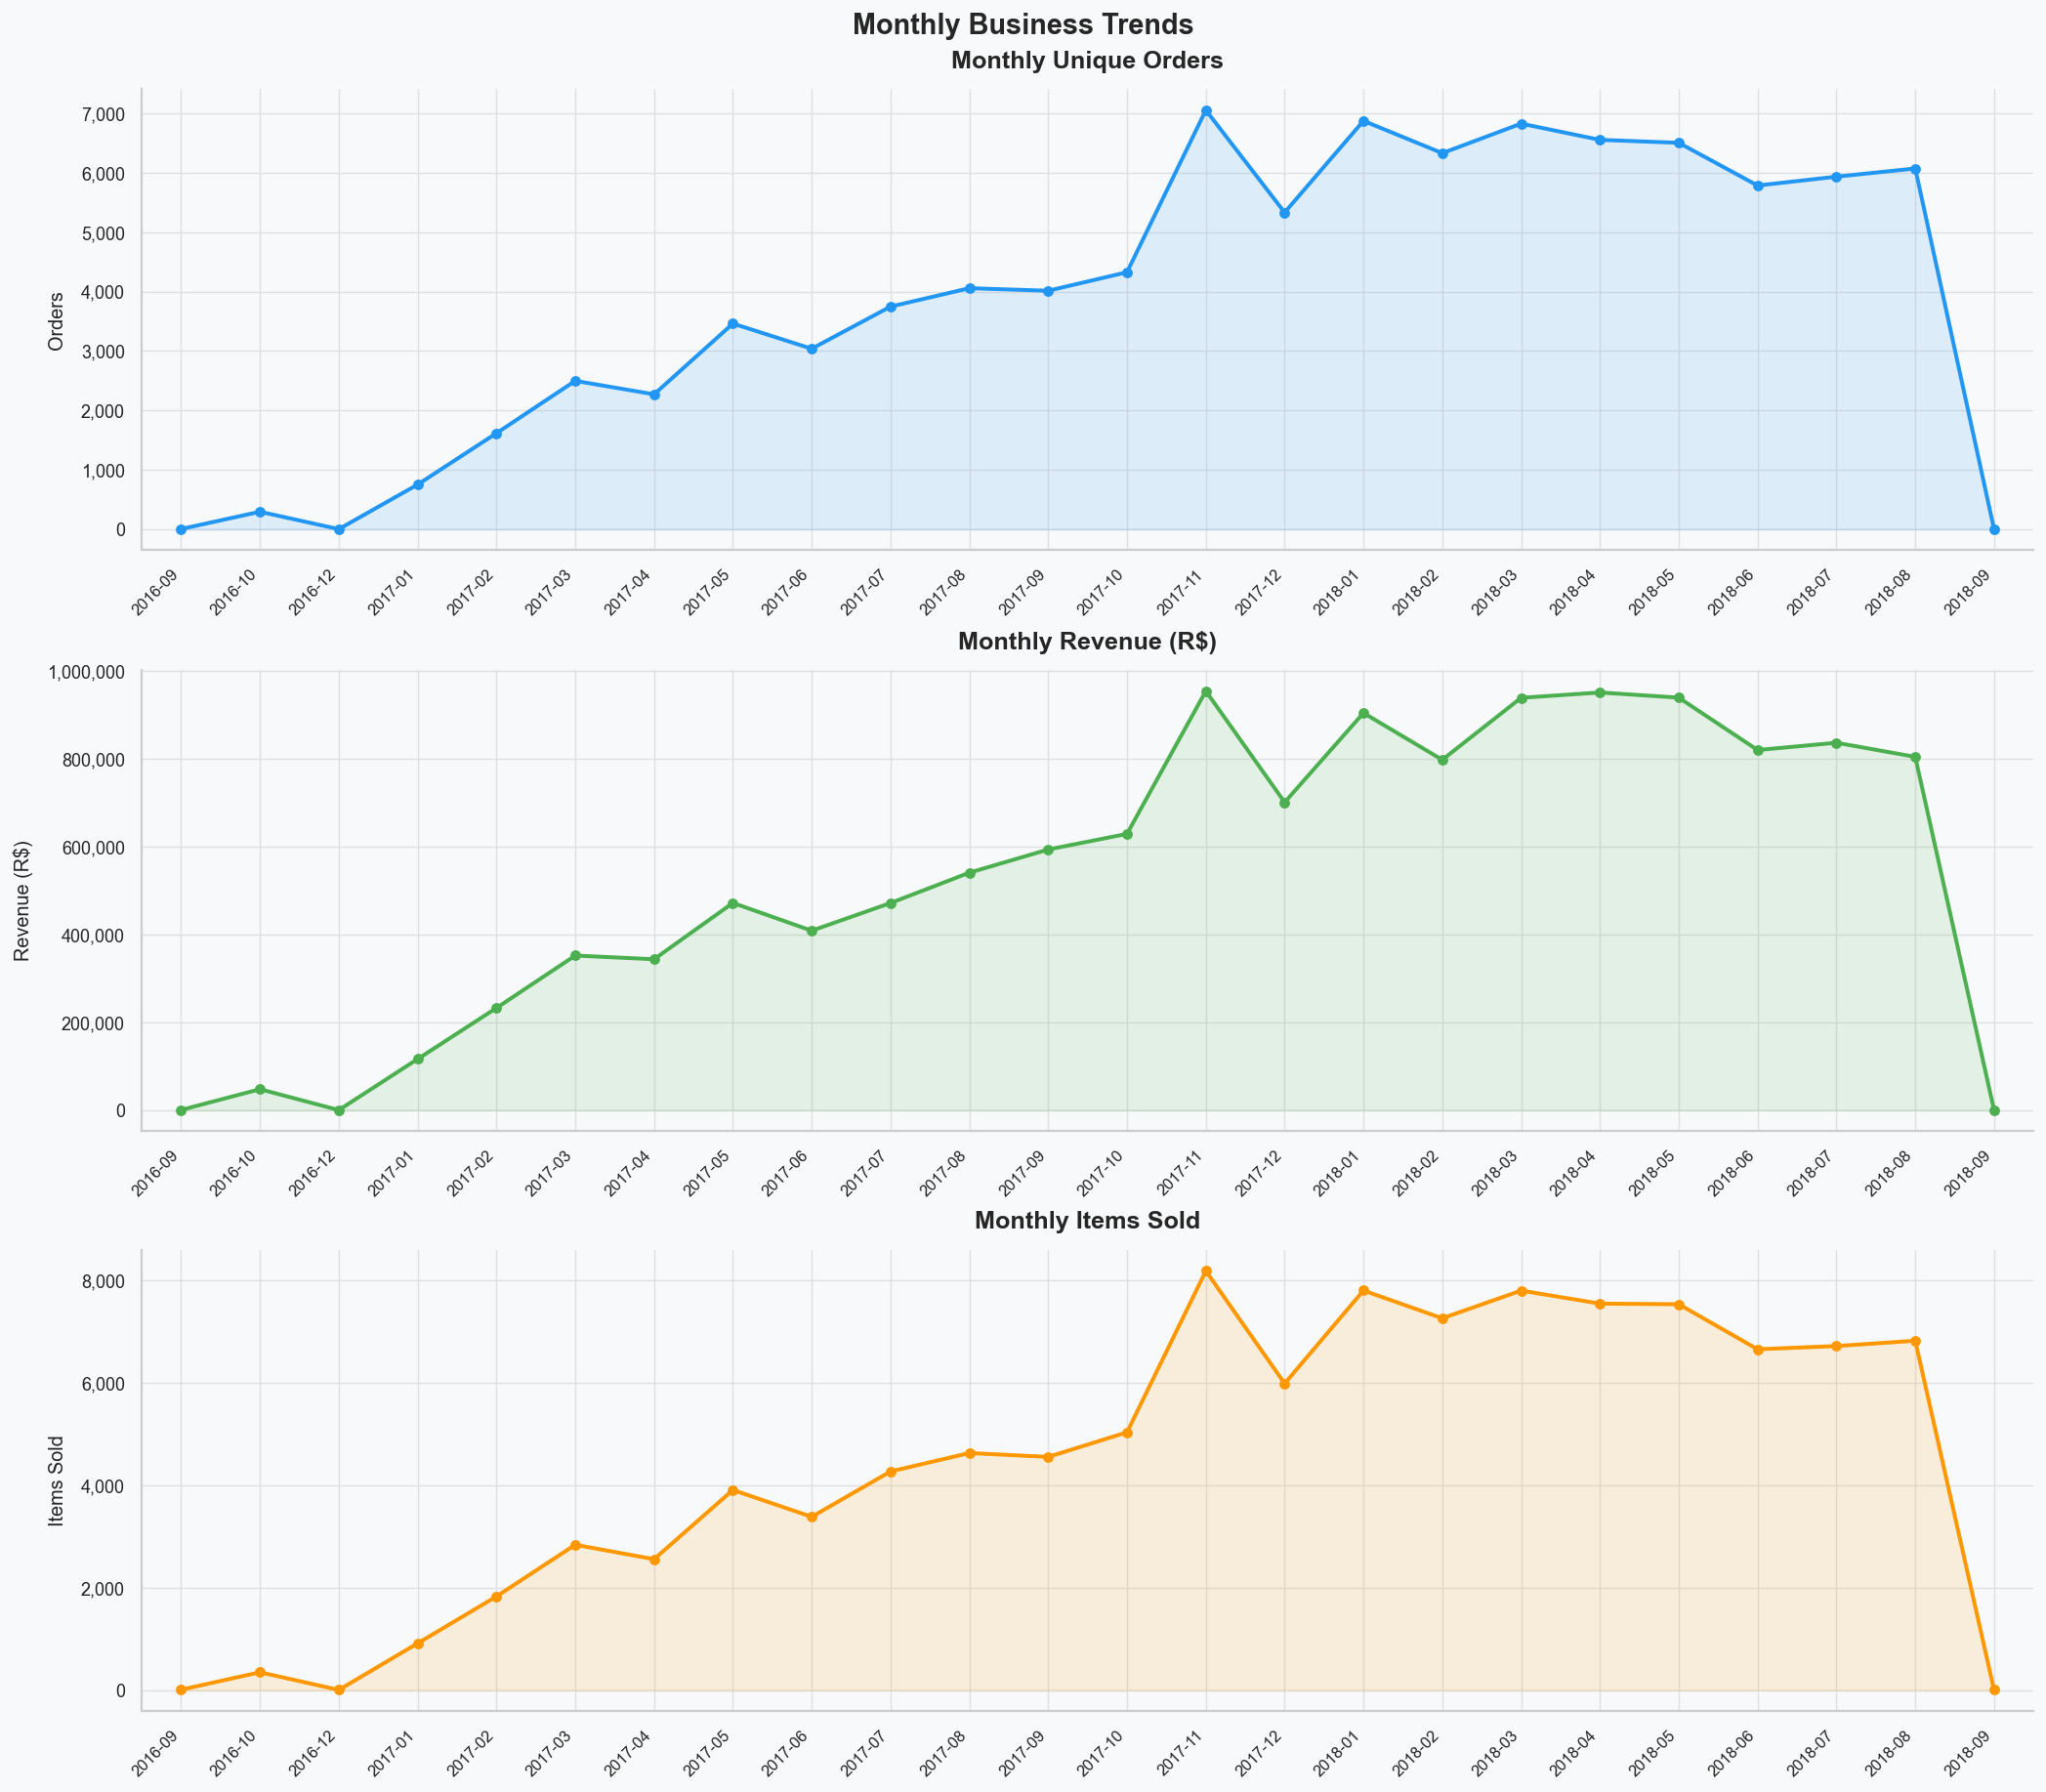

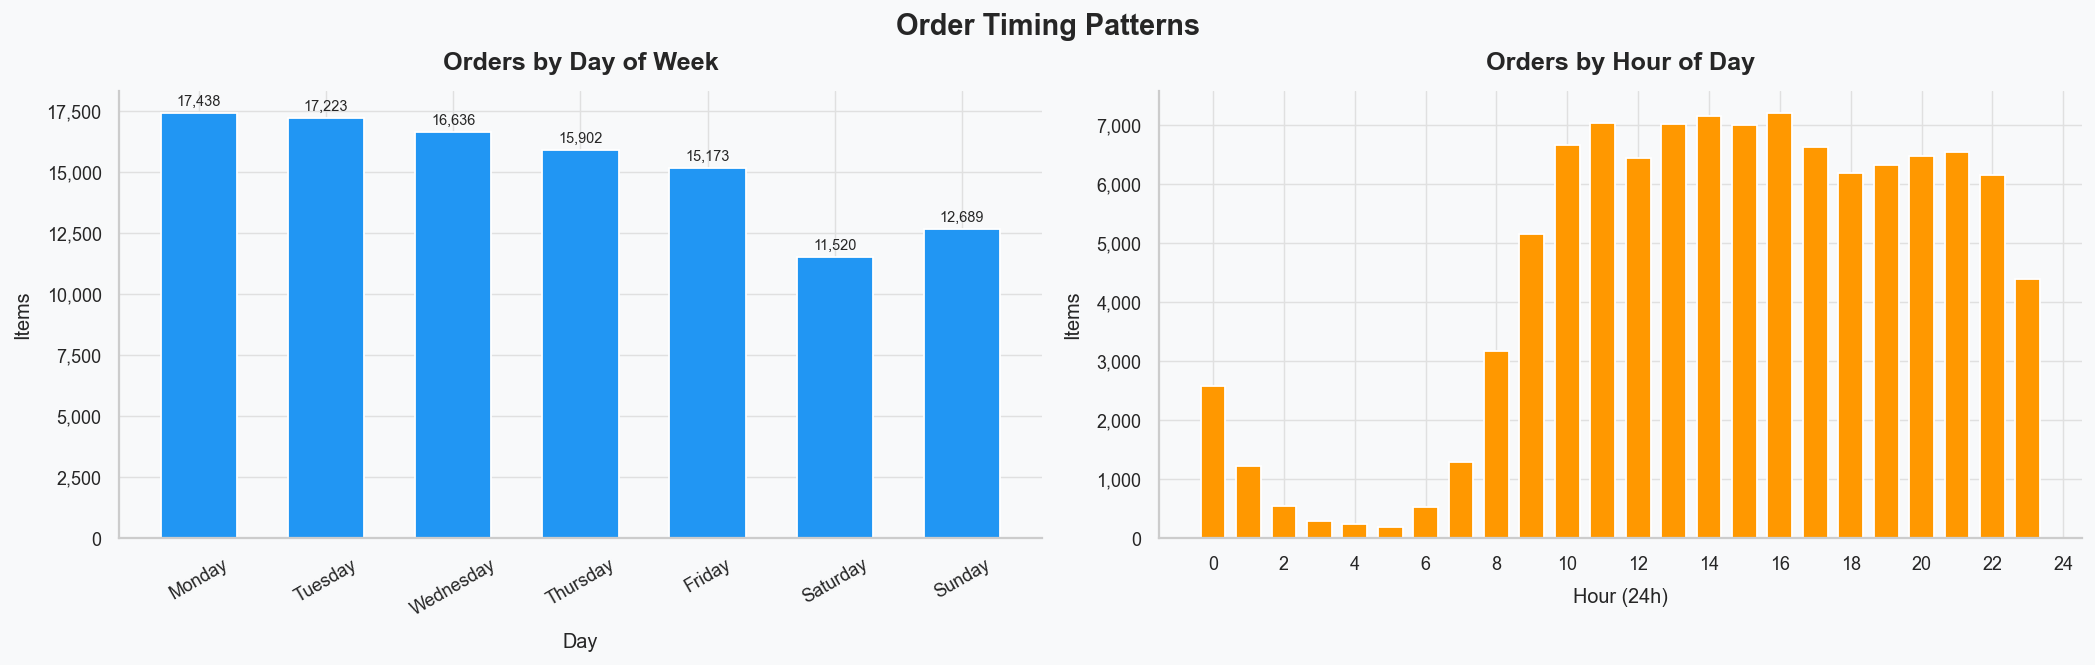

In [4]:
df["month"]       = df["order_purchase_timestamp"].dt.to_period("M")
df["day_of_week"] = df["order_purchase_timestamp"].dt.day_name()
df["hour"]        = df["order_purchase_timestamp"].dt.hour

monthly_orders  = df.drop_duplicates("order_id").groupby("month").size()
monthly_revenue = df.groupby("month")["price"].sum()
monthly_items   = df.groupby("month").size()
x_labels = [str(p) for p in monthly_orders.index]

fig, axes = plt.subplots(3, 1, figsize=(16, 14))
fig.suptitle("Monthly Business Trends", fontsize=16, fontweight="bold")

for ax, series, color, ylabel, title in zip(
    axes,
    [monthly_orders, monthly_revenue, monthly_items],
    ["#2196F3", "#4CAF50", "#FF9800"],
    ["Orders", "Revenue (R$)", "Items Sold"],
    ["Monthly Unique Orders", "Monthly Revenue (R$)", "Monthly Items Sold"]
):
    ax.plot(x_labels, series.values, marker="o", color=color,
            linewidth=2.2, markersize=5, zorder=3)
    ax.fill_between(x_labels, series.values, alpha=0.12, color=color)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xticks(range(len(x_labels)))
    ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.set_xlim(-0.5, len(x_labels) - 0.5)

plt.show()

# Day-of-week & Hour
dow_order   = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
dow_counts  = df["day_of_week"].value_counts().reindex(dow_order)
hour_counts = df["hour"].value_counts().sort_index()

fig2, axes2 = plt.subplots(1, 2, figsize=(16, 5))
fig2.suptitle("Order Timing Patterns", fontsize=16, fontweight="bold")

bars_dow = axes2[0].bar(dow_counts.index, dow_counts.values,
                        color="#2196F3", edgecolor="white", width=0.6)
axes2[0].set_title("Orders by Day of Week")
axes2[0].set_xlabel("Day")
axes2[0].set_ylabel("Items")
axes2[0].tick_params(axis="x", rotation=30)
axes2[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for bar in bars_dow:
    axes2[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
                  f"{int(bar.get_height()):,}", ha="center", fontsize=8)

bars_hr = axes2[1].bar(hour_counts.index, hour_counts.values,
                       color="#FF9800", edgecolor="white", width=0.7)
axes2[1].set_title("Orders by Hour of Day")
axes2[1].set_xlabel("Hour (24h)")
axes2[1].set_ylabel("Items")
axes2[1].xaxis.set_major_locator(mticker.MultipleLocator(2))
axes2[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.show()


## 5. Product Category Analysis

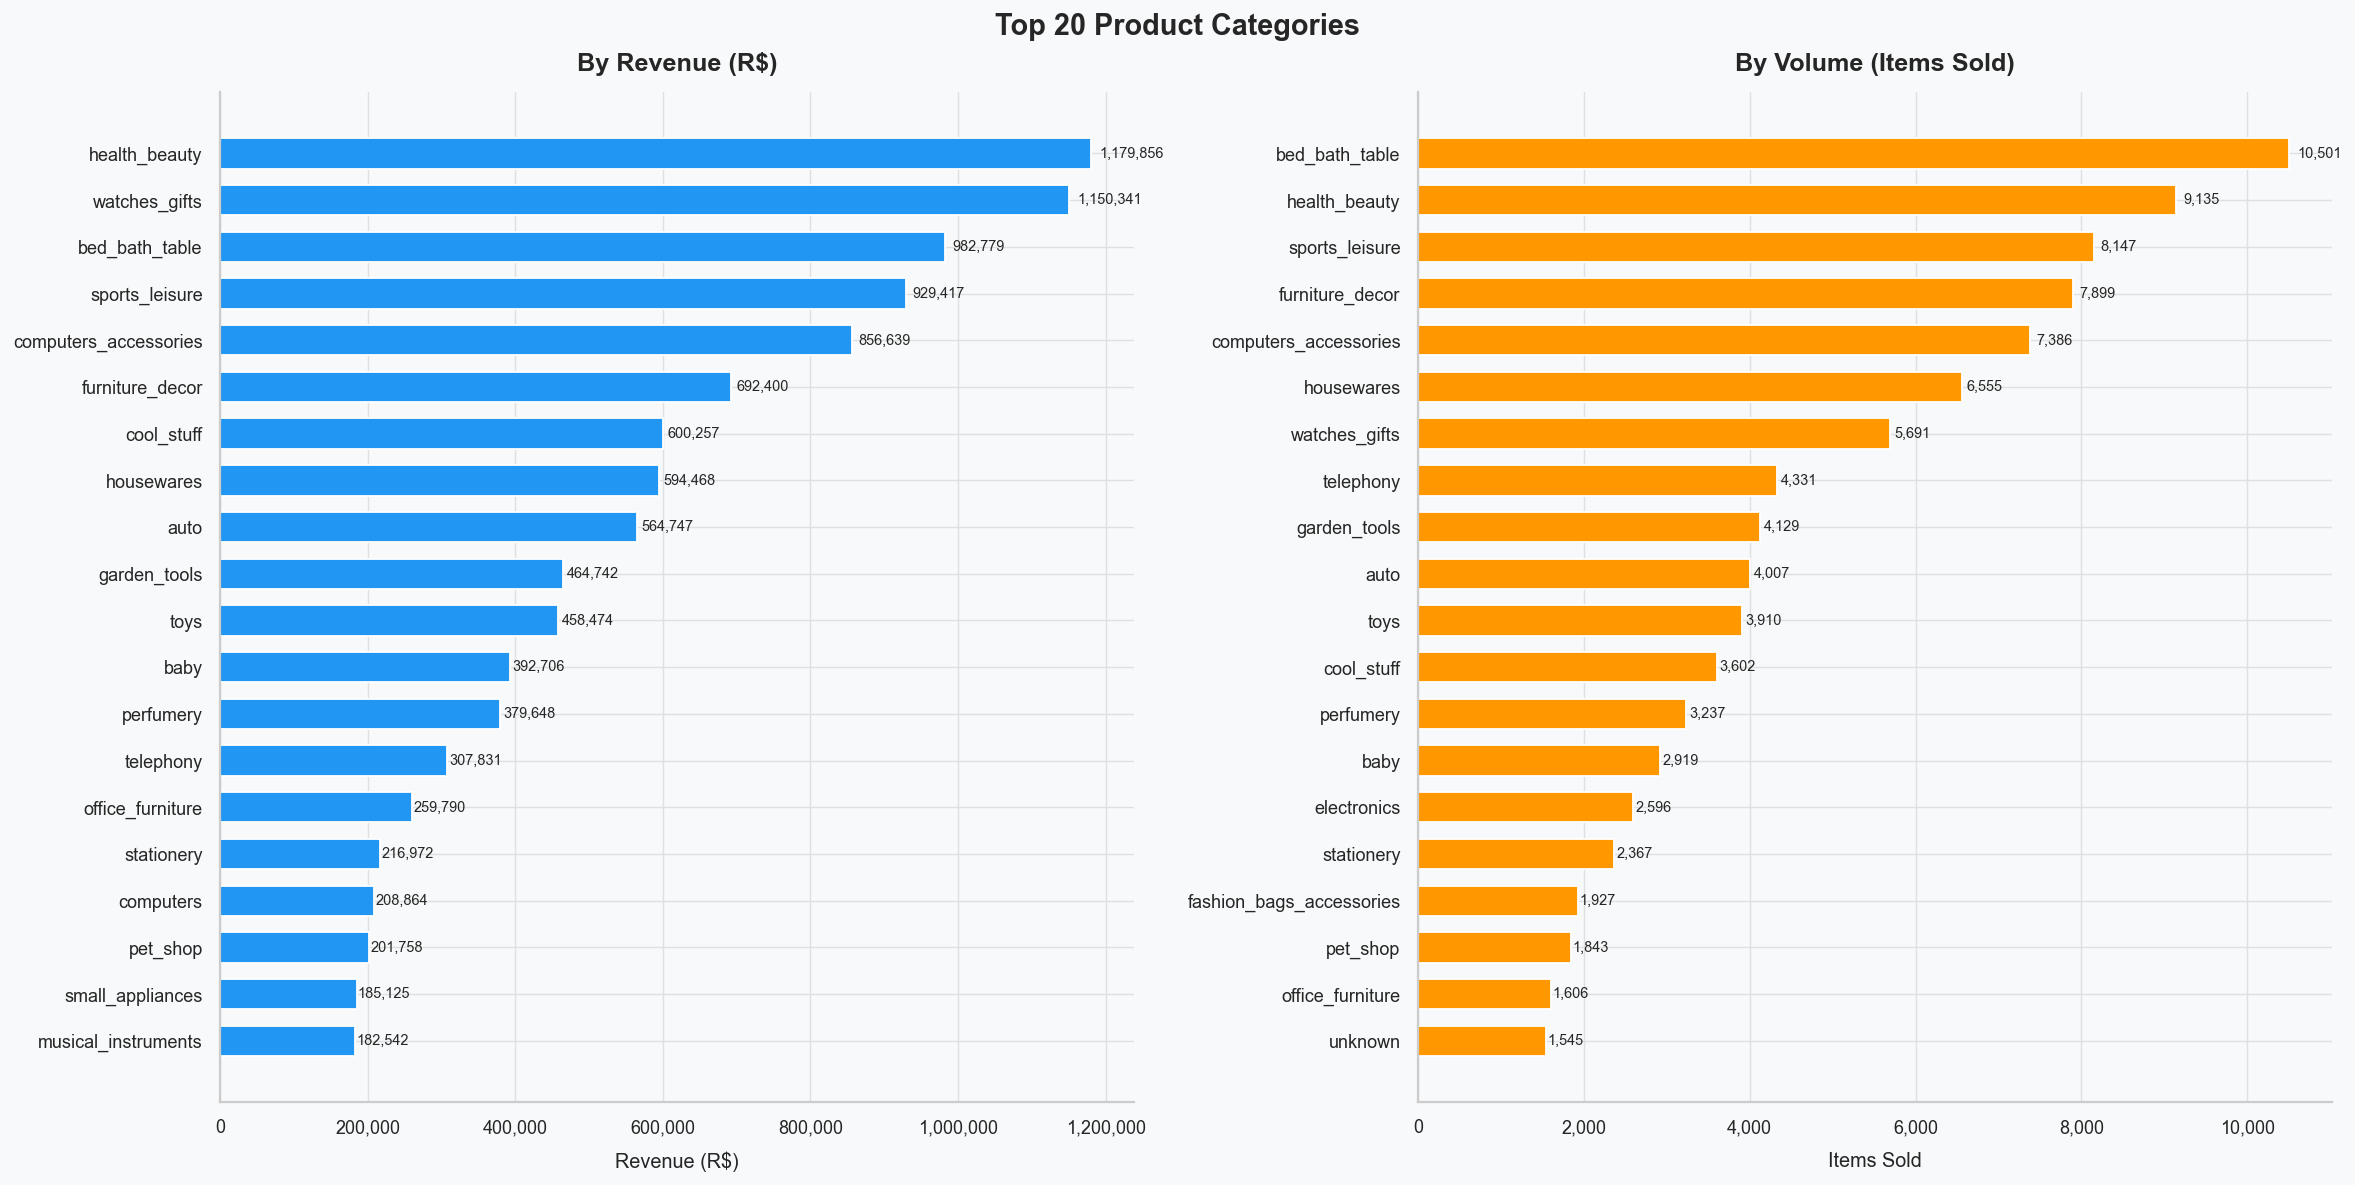

Top 10 Categories:
                               revenue (R$)    items
product_category_name_english                       
auto                              564747.09   4007.0
bed_bath_table                    982779.19  10501.0
computers_accessories             856639.22   7386.0
cool_stuff                        600257.91      NaN
furniture_decor                   692400.66   7899.0
garden_tools                      464742.04   4129.0
health_beauty                    1179856.81   9135.0
housewares                        594468.56   6555.0
sports_leisure                    929417.21   8147.0
telephony                               NaN   4331.0
watches_gifts                    1150341.01   5691.0


In [5]:
cat_revenue = df.groupby("product_category_name_english")["price"].sum().sort_values(ascending=False).head(20)
cat_volume  = df.groupby("product_category_name_english").size().sort_values(ascending=False).head(20)

fig, axes = plt.subplots(1, 2, figsize=(18, 9))
fig.suptitle("Top 20 Product Categories", fontsize=16, fontweight="bold")

for ax, series, color, xlabel, title in zip(
    axes,
    [cat_revenue.sort_values(), cat_volume.sort_values()],
    ["#2196F3", "#FF9800"],
    ["Revenue (R$)", "Items Sold"],
    ["By Revenue (R$)", "By Volume (Items Sold)"]
):
    bars = ax.barh(series.index, series.values, color=color, edgecolor="white", height=0.65)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    for bar in bars:
        w = bar.get_width()
        ax.text(w * 1.01, bar.get_y() + bar.get_height()/2,
                f"{int(w):,}", va="center", fontsize=8)

plt.show()

top10_cat = pd.DataFrame({"revenue (R$)": cat_revenue.head(10).round(2),
                           "items": cat_volume.head(10)})
print("Top 10 Categories:")
print(top10_cat.to_string())


## 6. Pricing & Freight Analysis

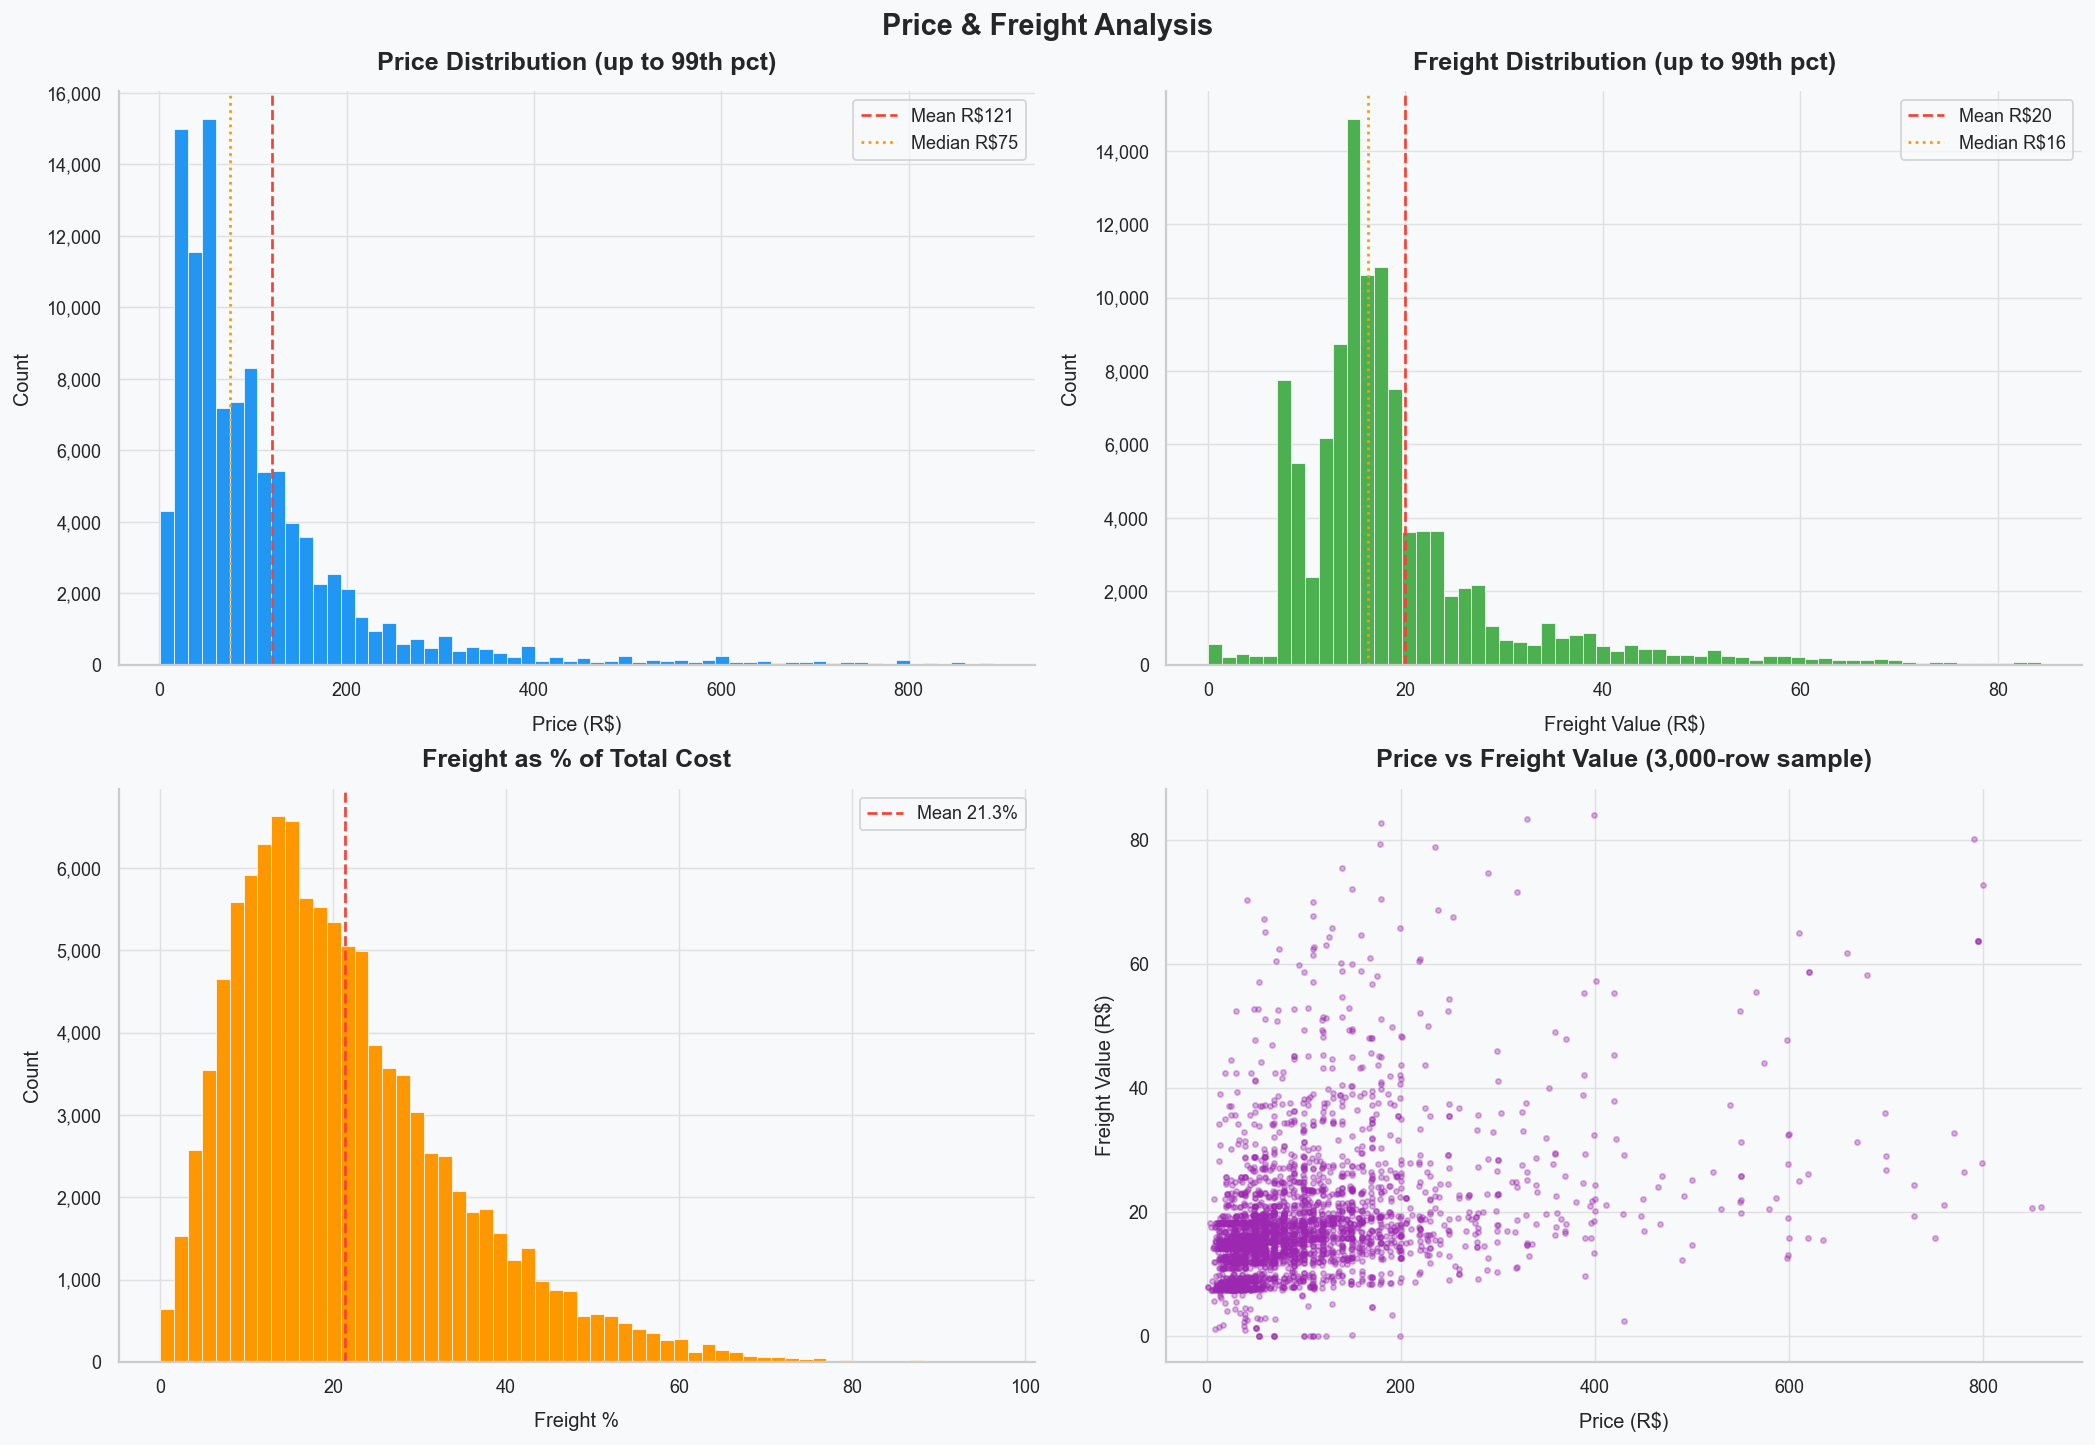

Median price   : R$ 74.99  |  Mean price   : R$ 120.69
Median freight : R$ 16.26  |  Mean freight : R$ 19.98
Mean freight % : 21.3%


In [6]:
df["freight_pct"] = df["freight_value"] / (df["price"] + df["freight_value"]) * 100

price_99    = df["price"].quantile(0.99)
freight_99  = df["freight_value"].quantile(0.99)
price_med   = df["price"].median()
price_mean  = df["price"].mean()
freight_med = df["freight_value"].median()
freight_mean= df["freight_value"].mean()
freight_pct_mean = df["freight_pct"].mean()

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("Price & Freight Analysis", fontsize=16, fontweight="bold")

# Price
axes[0,0].hist(df[df["price"] <= price_99]["price"], bins=60,
               color="#2196F3", edgecolor="white", linewidth=0.4)
axes[0,0].axvline(price_mean, color="#F44336", linestyle="--", linewidth=1.5,
                  label=f"Mean R${price_mean:.0f}")
axes[0,0].axvline(price_med,  color="#FF9800", linestyle=":",  linewidth=1.5,
                  label=f"Median R${price_med:.0f}")
axes[0,0].set_title("Price Distribution (up to 99th pct)")
axes[0,0].set_xlabel("Price (R$)")
axes[0,0].set_ylabel("Count")
axes[0,0].legend()
axes[0,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Freight
axes[0,1].hist(df[df["freight_value"] <= freight_99]["freight_value"], bins=60,
               color="#4CAF50", edgecolor="white", linewidth=0.4)
axes[0,1].axvline(freight_mean, color="#F44336", linestyle="--", linewidth=1.5,
                  label=f"Mean R${freight_mean:.0f}")
axes[0,1].axvline(freight_med,  color="#FF9800", linestyle=":",  linewidth=1.5,
                  label=f"Median R${freight_med:.0f}")
axes[0,1].set_title("Freight Distribution (up to 99th pct)")
axes[0,1].set_xlabel("Freight Value (R$)")
axes[0,1].set_ylabel("Count")
axes[0,1].legend()
axes[0,1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Freight %
axes[1,0].hist(df["freight_pct"].clip(0,100), bins=60,
               color="#FF9800", edgecolor="white", linewidth=0.4)
axes[1,0].axvline(freight_pct_mean, color="#F44336", linestyle="--", linewidth=1.5,
                  label=f"Mean {freight_pct_mean:.1f}%")
axes[1,0].set_title("Freight as % of Total Cost")
axes[1,0].set_xlabel("Freight %")
axes[1,0].set_ylabel("Count")
axes[1,0].legend()
axes[1,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Scatter
sample = df[(df["price"] <= price_99) & (df["freight_value"] <= freight_99)].sample(min(3000, len(df)), random_state=42)
axes[1,1].scatter(sample["price"], sample["freight_value"],
                  alpha=0.35, s=8, color="#9C27B0")
axes[1,1].set_title("Price vs Freight Value (3,000-row sample)")
axes[1,1].set_xlabel("Price (R$)")
axes[1,1].set_ylabel("Freight Value (R$)")

plt.show()
print(f"Median price   : R$ {price_med:.2f}  |  Mean price   : R$ {price_mean:.2f}")
print(f"Median freight : R$ {freight_med:.2f}  |  Mean freight : R$ {freight_mean:.2f}")
print(f"Mean freight % : {freight_pct_mean:.1f}%")


## 7. Payment Analysis

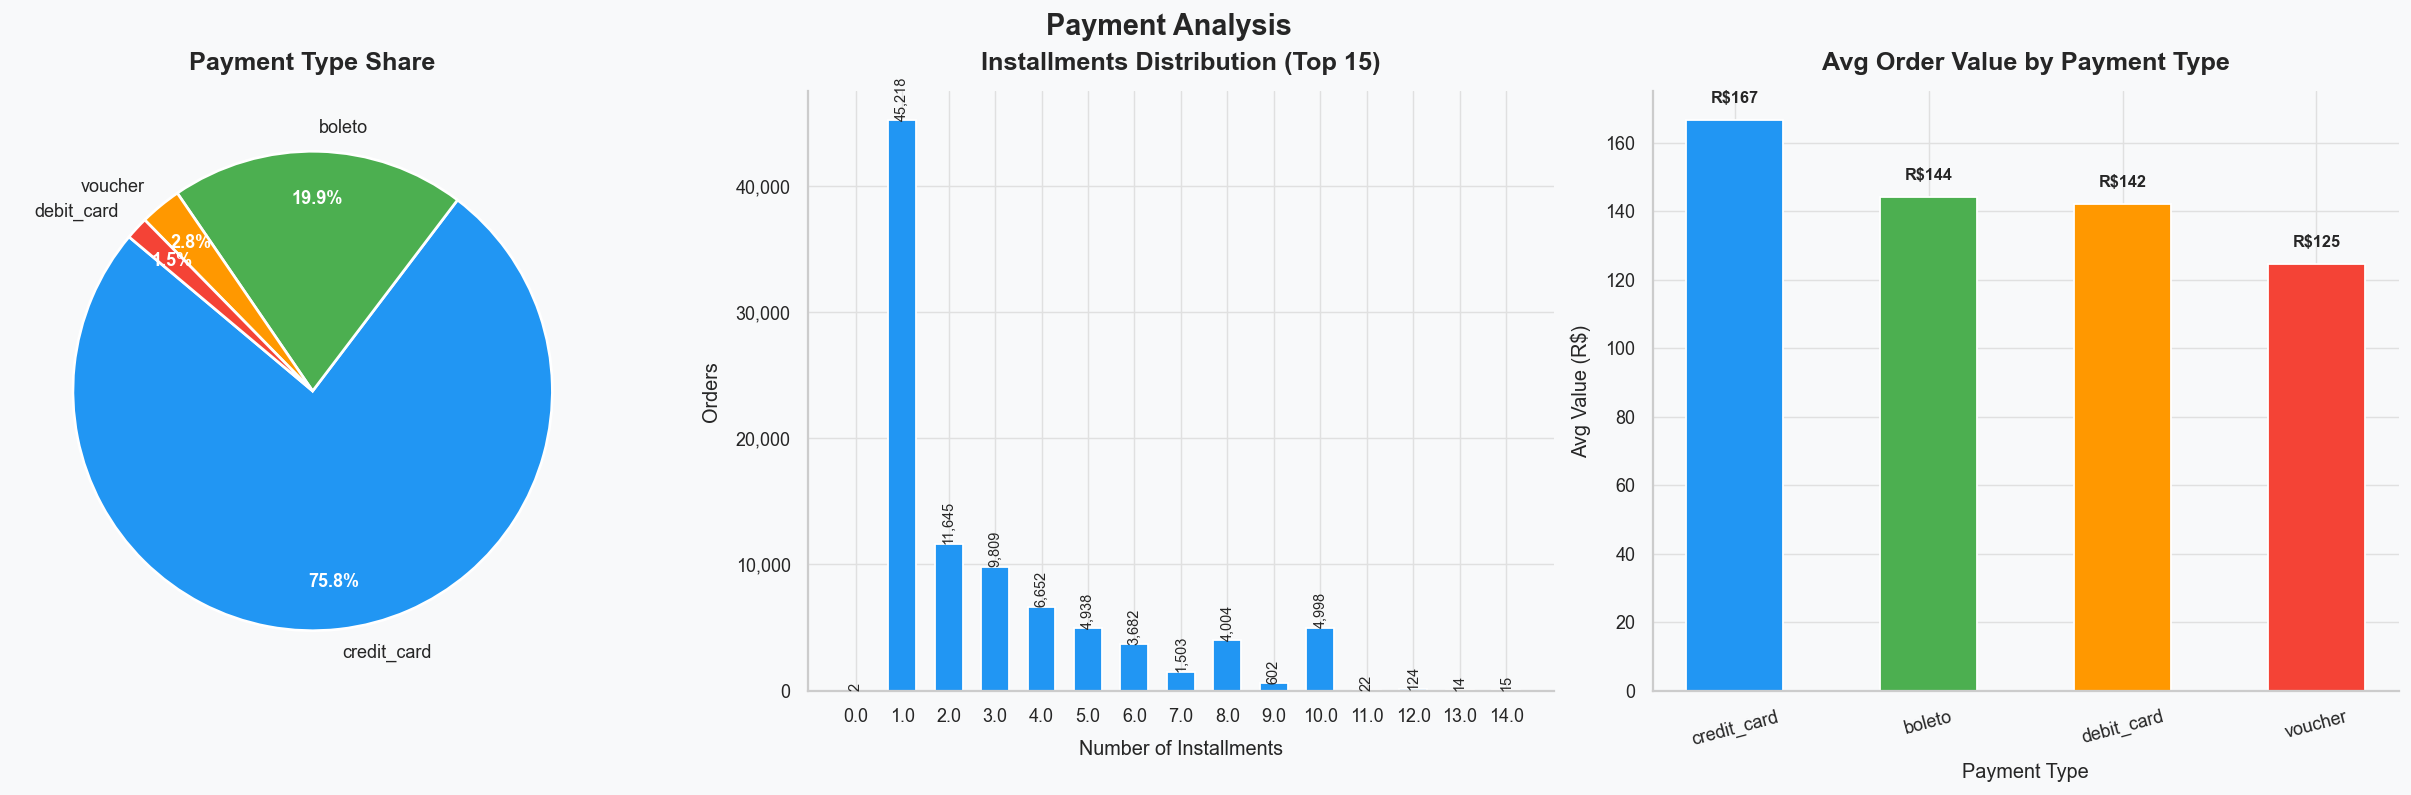

              orders  avg_value  total_value
payment_type                                
boleto         18559     144.05   2673402.15
credit_card    70757     166.66  11792403.47
debit_card      1434     142.02    203661.82
voucher         2618     124.52    325990.06


In [7]:
orders_pay = df.drop_duplicates("order_id")[["order_id","payment_type",
                                                      "payment_installments","payment_total_value"]]
pay_type_counts   = orders_pay["payment_type"].value_counts()
install_counts    = orders_pay["payment_installments"].value_counts().sort_index().head(15)
avg_order_by_type = orders_pay.groupby("payment_type")["payment_total_value"].mean().sort_values(ascending=False)

PAY_COLORS = ["#2196F3","#4CAF50","#FF9800","#F44336"]

fig, axes = plt.subplots(1, 3, figsize=(19, 6))
fig.suptitle("Payment Analysis", fontsize=16, fontweight="bold")

# Pie
wedges, texts, autotexts = axes[0].pie(
    pay_type_counts.values, labels=pay_type_counts.index,
    autopct="%1.1f%%", startangle=140,
    colors=PAY_COLORS, wedgeprops=dict(edgecolor="white", linewidth=1.5),
    pctdistance=0.80
)
for t in autotexts:
    t.set_fontsize(10); t.set_fontweight("bold"); t.set_color("white")
axes[0].set_title("Payment Type Share")

# Installments
bars = axes[1].bar(install_counts.index.astype(str), install_counts.values,
                   color="#2196F3", edgecolor="white", width=0.6)
axes[1].set_title("Installments Distribution (Top 15)")
axes[1].set_xlabel("Number of Installments")
axes[1].set_ylabel("Orders")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f"{int(bar.get_height()):,}", ha="center", fontsize=8, rotation=90)

# Avg value by type
bars2 = axes[2].bar(avg_order_by_type.index, avg_order_by_type.values,
                    color=PAY_COLORS[:len(avg_order_by_type)], edgecolor="white", width=0.5)
axes[2].set_title("Avg Order Value by Payment Type")
axes[2].set_xlabel("Payment Type")
axes[2].set_ylabel("Avg Value (R$)")
axes[2].tick_params(axis="x", rotation=15)
for bar in bars2:
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f"R${bar.get_height():.0f}", ha="center", fontsize=ANNOT_FS, fontweight="bold")

plt.show()

pay_summary = orders_pay.groupby("payment_type").agg(
    orders=("order_id", "count"),
    avg_value=("payment_total_value", "mean"),
    total_value=("payment_total_value", "sum")
).round(2)
print(pay_summary.to_string())


## 8. Delivery Performance

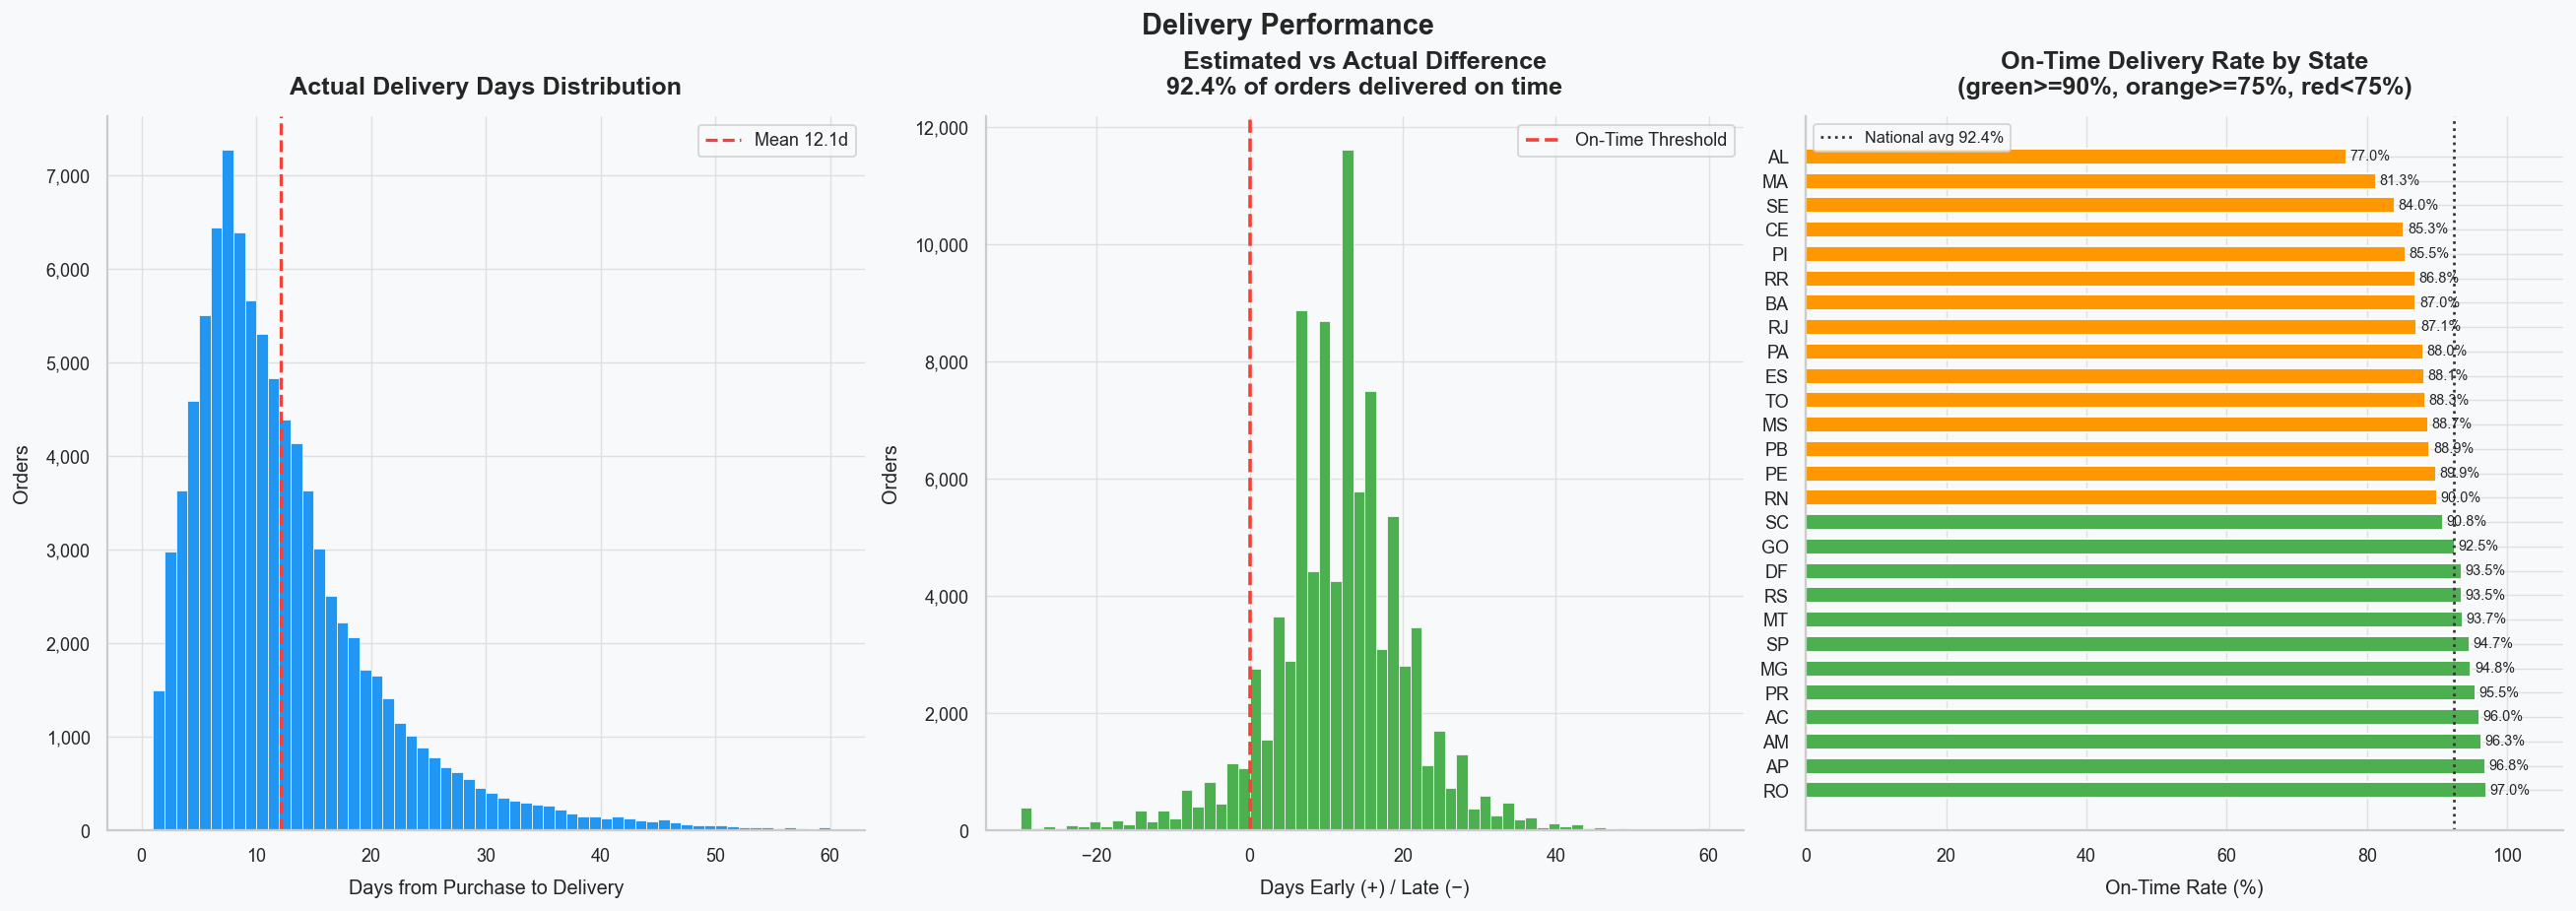

Overall on-time rate  : 92.4%
Avg actual delivery   : 12.1 days
Avg estimated delivery: 23.4 days


In [8]:
delivered = df[df["order_status"] == "delivered"].drop_duplicates("order_id").copy()
delivered = delivered.dropna(subset=["order_delivered_customer_date",
                                     "order_purchase_timestamp",
                                     "order_estimated_delivery_date"])

delivered["actual_days"]    = (delivered["order_delivered_customer_date"] - delivered["order_purchase_timestamp"]).dt.days
delivered["estimated_days"] = (delivered["order_estimated_delivery_date"] - delivered["order_purchase_timestamp"]).dt.days
delivered["days_diff"]      = delivered["estimated_days"] - delivered["actual_days"]
delivered["on_time"]        = delivered["days_diff"] >= 0

on_time_by_state = delivered.groupby("customer_state")["on_time"].mean().sort_values(ascending=False) * 100
on_time_pct      = delivered["on_time"].mean() * 100

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle("Delivery Performance", fontsize=16, fontweight="bold")

# Actual delivery days
mean_days = delivered["actual_days"].mean()
axes[0].hist(delivered[delivered["actual_days"].between(0,60)]["actual_days"],
             bins=60, color="#2196F3", edgecolor="white", linewidth=0.4)
axes[0].axvline(mean_days, color="#F44336", linestyle="--", linewidth=1.8,
                label=f"Mean {mean_days:.1f}d")
axes[0].set_title("Actual Delivery Days Distribution")
axes[0].set_xlabel("Days from Purchase to Delivery")
axes[0].set_ylabel("Orders")
axes[0].legend()
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Days diff
axes[1].hist(delivered["days_diff"].clip(-30, 60), bins=60,
             color="#4CAF50", edgecolor="white", linewidth=0.4)
axes[1].axvline(0, color="#F44336", linestyle="--", linewidth=2, label="On-Time Threshold")
axes[1].set_title(f"Estimated vs Actual Difference\n{on_time_pct:.1f}% of orders delivered on time")
axes[1].set_xlabel("Days Early (+) / Late (−)")
axes[1].set_ylabel("Orders")
axes[1].legend()
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# On-time by state
colors_state = ["#4CAF50" if v >= 90 else "#FF9800" if v >= 75 else "#F44336"
                for v in on_time_by_state.values]
bars = axes[2].barh(on_time_by_state.index, on_time_by_state.values,
                    color=colors_state, edgecolor="white", height=0.65)
axes[2].axvline(on_time_pct, color="#333333", linestyle=":", linewidth=1.5,
                label=f"National avg {on_time_pct:.1f}%")
axes[2].set_title("On-Time Delivery Rate by State\n(green>=90%, orange>=75%, red<75%)")
axes[2].set_xlabel("On-Time Rate (%)")
axes[2].set_xlim(0, 108)
axes[2].legend(fontsize=9)
for bar in bars:
    w = bar.get_width()
    axes[2].text(w + 0.5, bar.get_y() + bar.get_height()/2,
                 f"{w:.1f}%", va="center", fontsize=8)

plt.show()
print(f"Overall on-time rate  : {on_time_pct:.1f}%")
print(f"Avg actual delivery   : {delivered['actual_days'].mean():.1f} days")
print(f"Avg estimated delivery: {delivered['estimated_days'].mean():.1f} days")


## 9. Customer Review Analysis

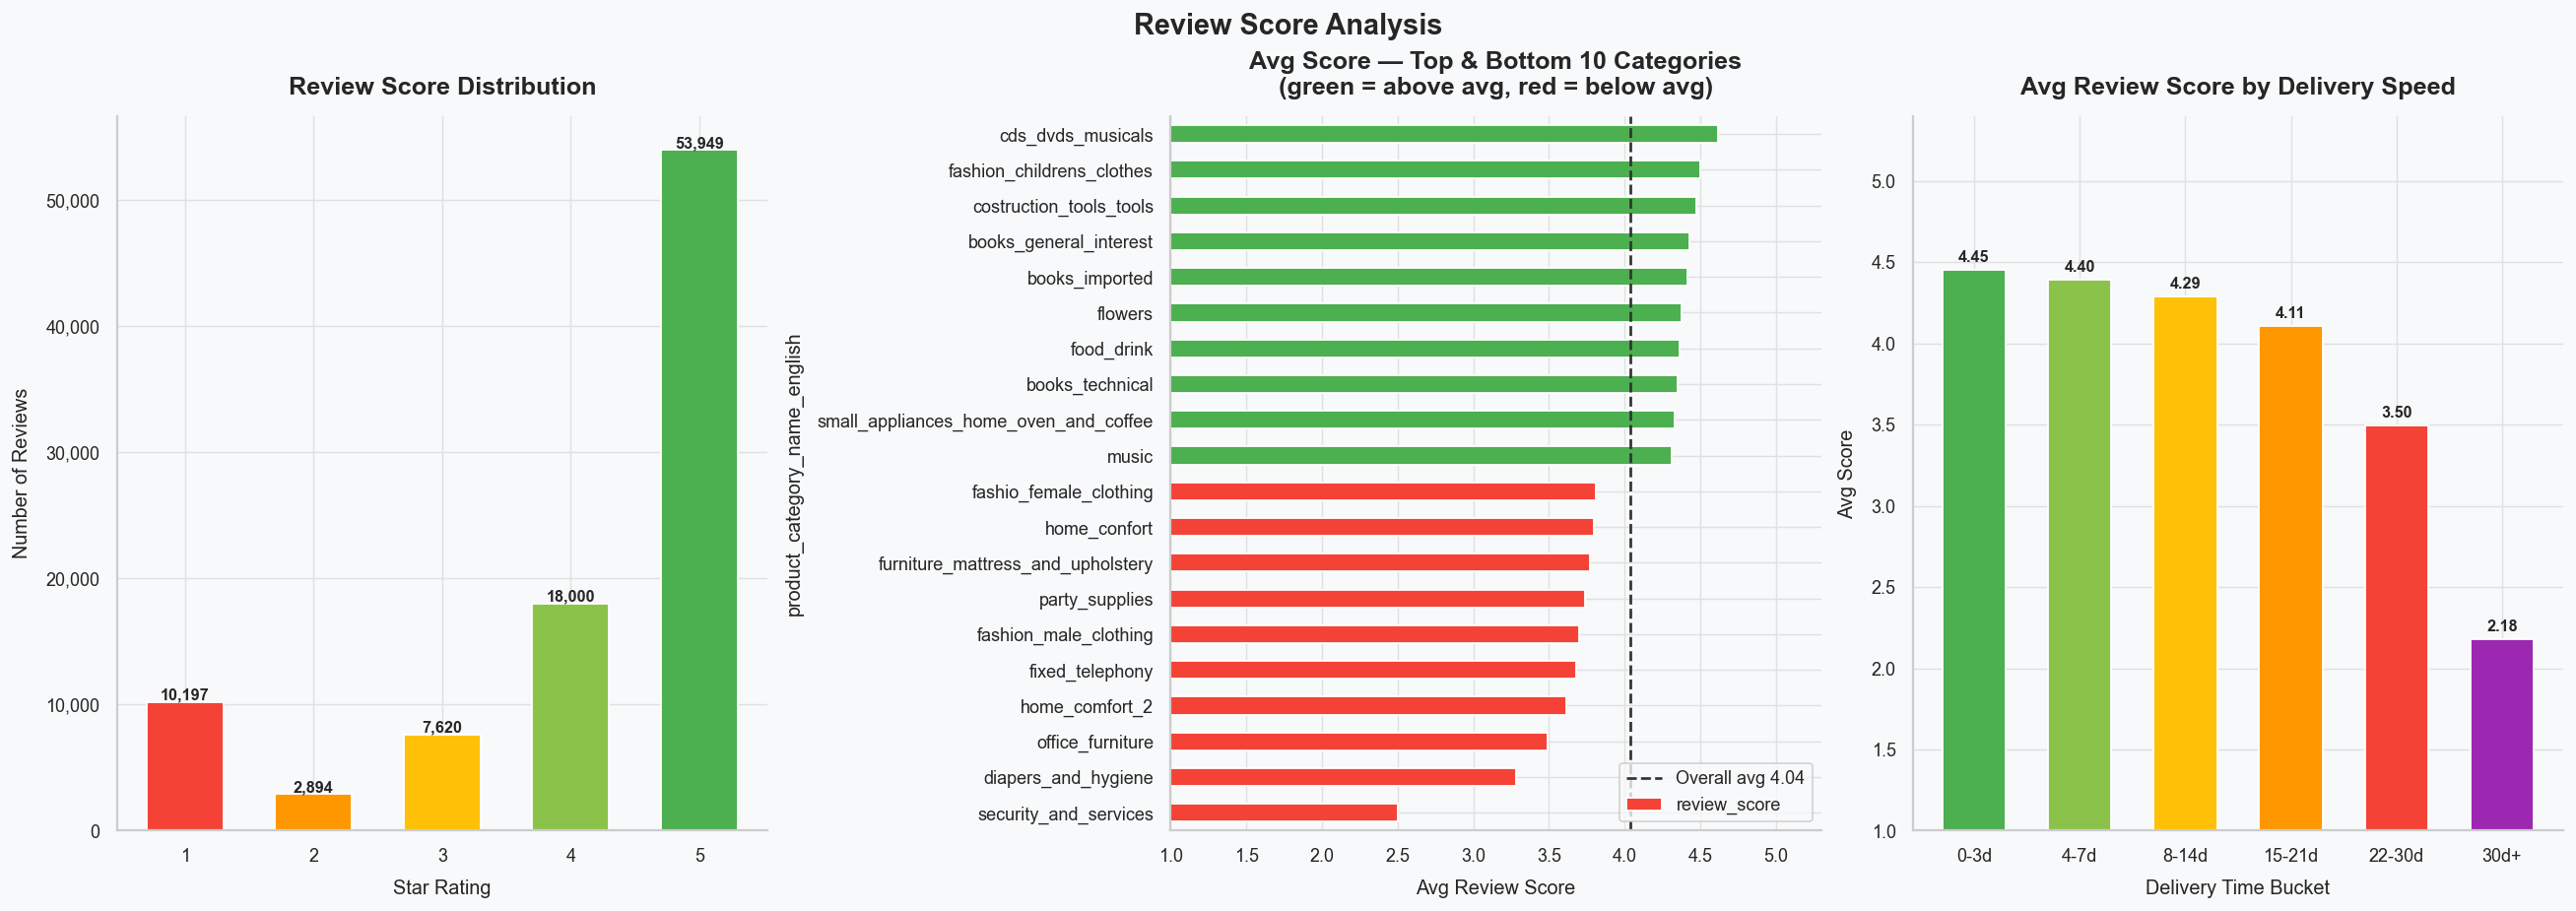

Overall avg review score: 4.04


In [9]:
reviews = df.dropna(subset=["review_score"]).copy()
score_counts = reviews.drop_duplicates("order_id")["review_score"].value_counts().sort_index()

avg_score_cat   = reviews.groupby("product_category_name_english")["review_score"].mean()
top10_cat_score = avg_score_cat.sort_values(ascending=False).head(10)
bot10_cat_score = avg_score_cat.sort_values(ascending=True).head(10)
combined_score  = pd.concat([top10_cat_score, bot10_cat_score]).drop_duplicates().sort_values()

bins          = [0, 3, 7, 14, 21, 30, 9999]
bucket_labels = ["0-3d","4-7d","8-14d","15-21d","22-30d","30d+"]
delivered_reviews = delivered.dropna(subset=["actual_days","review_score"]).copy()
delivered_reviews["delivery_bucket"] = pd.cut(delivered_reviews["actual_days"], bins=bins, labels=bucket_labels)
avg_score_by_speed = delivered_reviews.groupby("delivery_bucket", observed=True)["review_score"].mean()

SCORE_COLORS = ["#F44336","#FF9800","#FFC107","#8BC34A","#4CAF50"]

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle("Review Score Analysis", fontsize=16, fontweight="bold")

# Score distribution
bars = axes[0].bar(score_counts.index.astype(int), score_counts.values,
                   color=SCORE_COLORS, edgecolor="white", width=0.6)
axes[0].set_title("Review Score Distribution")
axes[0].set_xlabel("Star Rating")
axes[0].set_ylabel("Number of Reviews")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f"{int(bar.get_height()):,}", ha="center", fontsize=ANNOT_FS, fontweight="bold")

# Top & Bottom categories
overall_avg  = reviews["review_score"].mean()
colors_cb    = ["#F44336" if v < overall_avg else "#4CAF50" for v in combined_score.values]
combined_score.plot(kind="barh", ax=axes[1], color=colors_cb, edgecolor="white")
axes[1].axvline(overall_avg, color="#333333", linestyle="--", linewidth=1.5,
                label=f"Overall avg {overall_avg:.2f}")
axes[1].set_title("Avg Score — Top & Bottom 10 Categories\n(green = above avg, red = below avg)")
axes[1].set_xlabel("Avg Review Score")
axes[1].set_xlim(1, 5.3)
axes[1].legend()

# Score by delivery speed
speed_colors = ["#4CAF50","#8BC34A","#FFC107","#FF9800","#F44336","#9C27B0"]
bars2 = axes[2].bar(avg_score_by_speed.index, avg_score_by_speed.values,
                    color=speed_colors, edgecolor="white", width=0.6)
axes[2].set_title("Avg Review Score by Delivery Speed")
axes[2].set_xlabel("Delivery Time Bucket")
axes[2].set_ylabel("Avg Score")
axes[2].set_ylim(1, 5.4)
for bar in bars2:
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f"{bar.get_height():.2f}", ha="center", fontsize=ANNOT_FS, fontweight="bold")

plt.show()
print(f"Overall avg review score: {overall_avg:.2f}")


## 10. Geographic Analysis

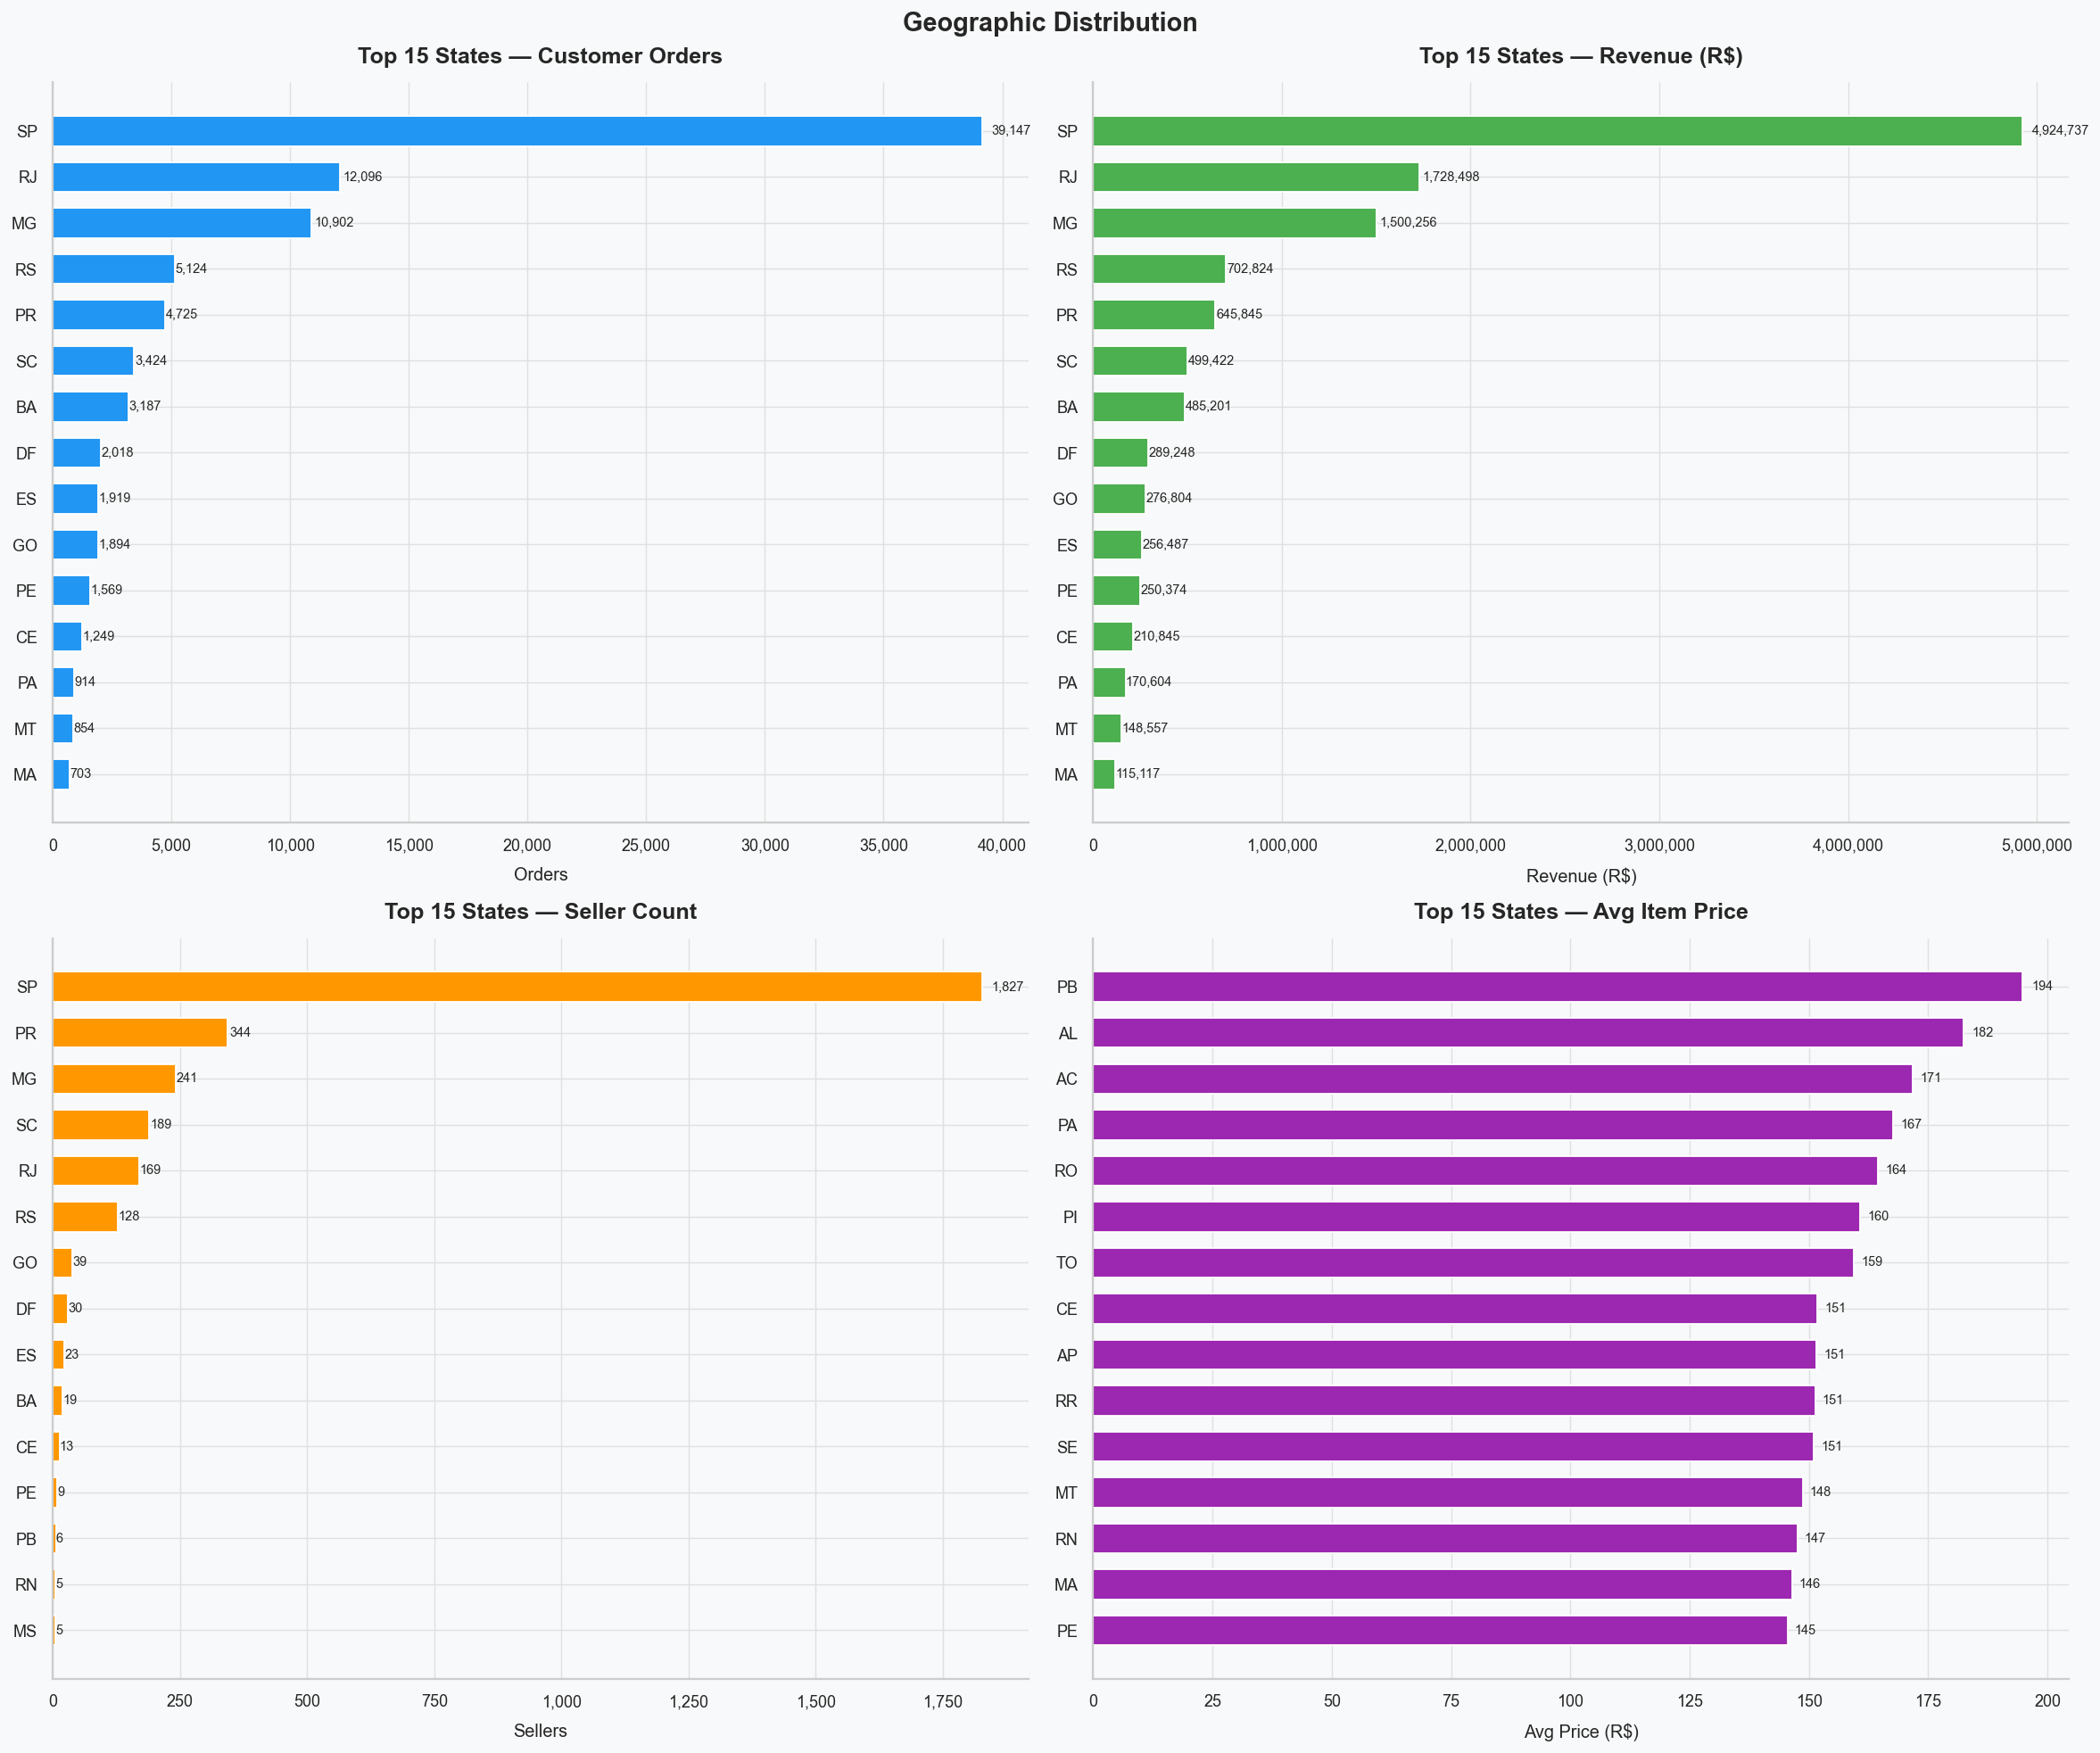

In [10]:
orders_by_state    = df.drop_duplicates("order_id").groupby("customer_state").size().sort_values(ascending=False)
revenue_by_state   = df.groupby("customer_state")["price"].sum().sort_values(ascending=False)
sellers_by_state   = df.drop_duplicates("seller_id").groupby("seller_state").size().sort_values(ascending=False)
avg_price_by_state = df.groupby("customer_state")["price"].mean().sort_values(ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(18, 15))
fig.suptitle("Geographic Distribution", fontsize=16, fontweight="bold")

datasets = [
    (orders_by_state.head(15).sort_values(),   "#2196F3", "Orders",           "Top 15 States — Customer Orders"),
    (revenue_by_state.head(15).sort_values(),  "#4CAF50", "Revenue (R$)",     "Top 15 States — Revenue (R$)"),
    (sellers_by_state.head(15).sort_values(),  "#FF9800", "Sellers",          "Top 15 States — Seller Count"),
    (avg_price_by_state.head(15).sort_values(),"#9C27B0", "Avg Price (R$)",   "Top 15 States — Avg Item Price"),
]

for ax, (series, color, xlabel, title) in zip(axes.flat, datasets):
    bars = ax.barh(series.index, series.values, color=color, edgecolor="white", height=0.65)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    for bar in bars:
        w = bar.get_width()
        ax.text(w * 1.01, bar.get_y() + bar.get_height()/2,
                f"{int(w):,}", va="center", fontsize=8)

plt.show()


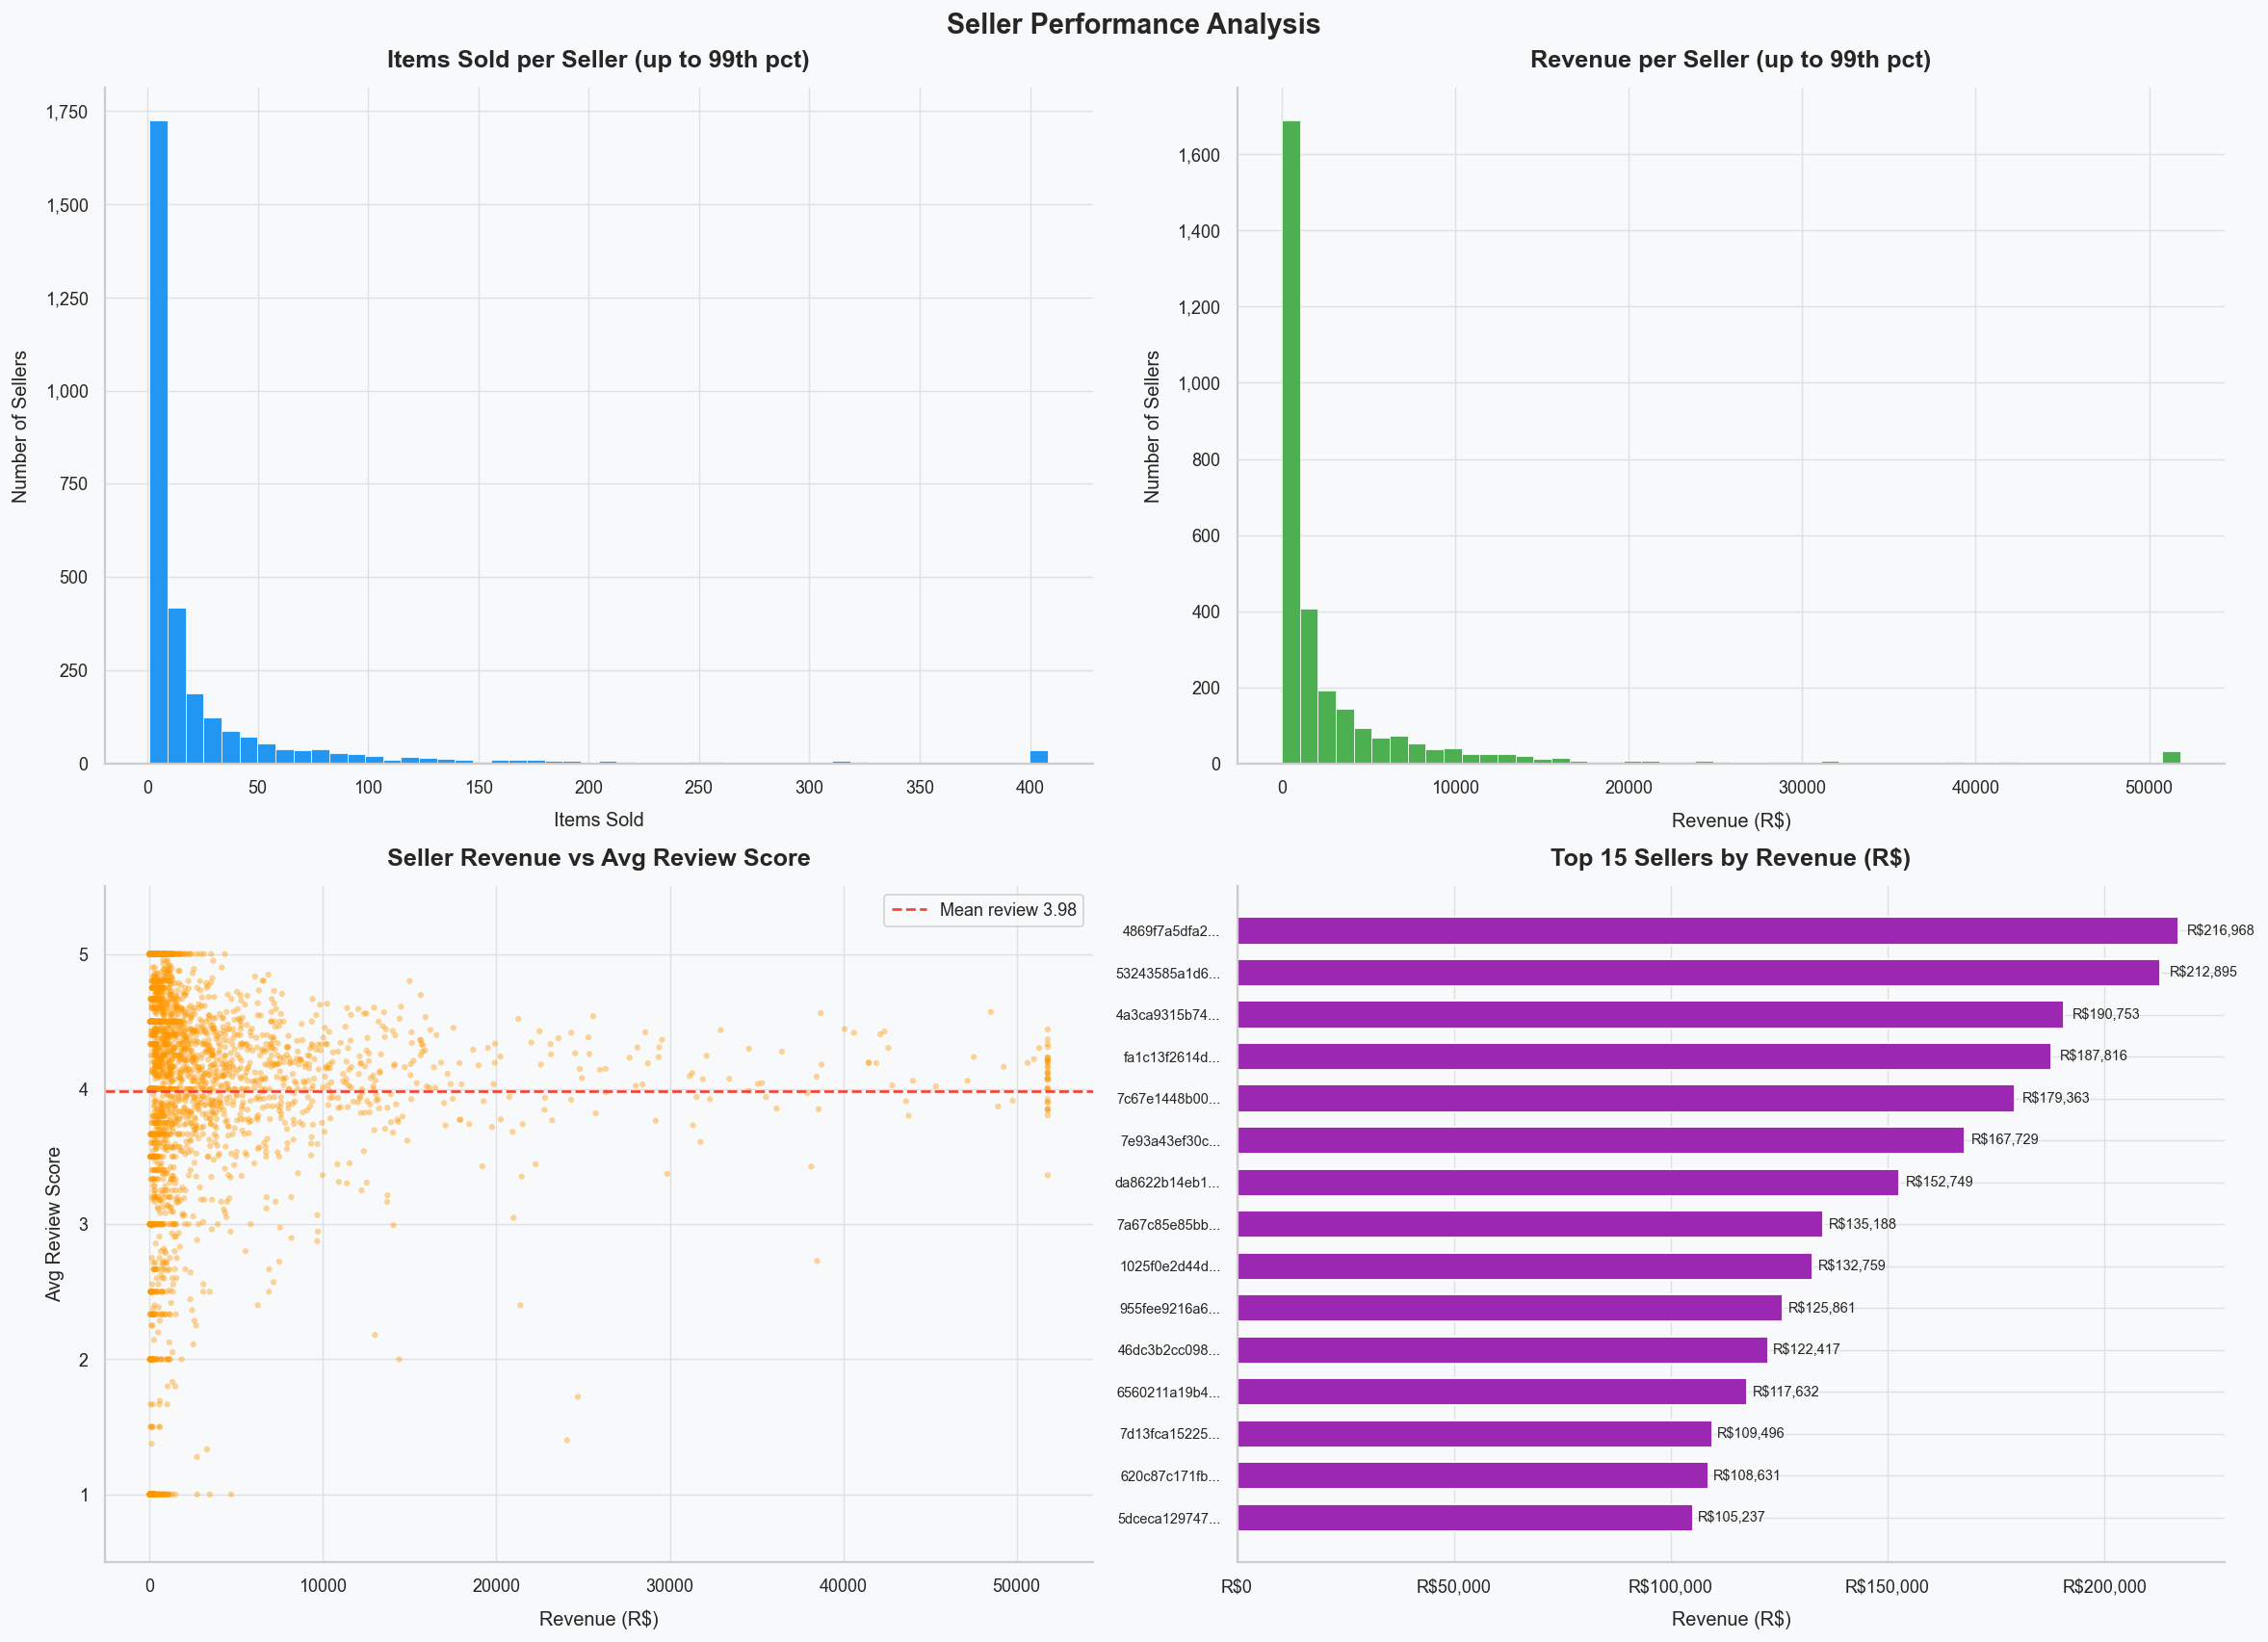

Total sellers: 3,060
Top 10% sellers (306) account for 67.5% of total revenue


In [11]:
seller_stats = df.groupby("seller_id").agg(
    items_sold   =("order_item_id", "count"),
    revenue      =("price", "sum"),
    unique_orders=("order_id", "nunique"),
    avg_price    =("price", "mean"),
    avg_review   =("review_score", "mean"),
    categories   =("product_category_name_english", "nunique")
).reset_index()

top15_sellers = seller_stats.nlargest(15, "revenue").set_index("seller_id")
items_p99     = seller_stats["items_sold"].quantile(0.99)
rev_p99       = seller_stats["revenue"].quantile(0.99)

fig, axes = plt.subplots(2, 2, figsize=(18, 13))
fig.suptitle("Seller Performance Analysis", fontsize=16, fontweight="bold")

# Items sold
axes[0,0].hist(seller_stats["items_sold"].clip(upper=items_p99), bins=50,
               color="#2196F3", edgecolor="white", linewidth=0.4)
axes[0,0].set_title("Items Sold per Seller (up to 99th pct)")
axes[0,0].set_xlabel("Items Sold")
axes[0,0].set_ylabel("Number of Sellers")
axes[0,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Revenue
axes[0,1].hist(seller_stats["revenue"].clip(upper=rev_p99), bins=50,
               color="#4CAF50", edgecolor="white", linewidth=0.4)
axes[0,1].set_title("Revenue per Seller (up to 99th pct)")
axes[0,1].set_xlabel("Revenue (R$)")
axes[0,1].set_ylabel("Number of Sellers")
axes[0,1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Scatter
mean_review = seller_stats["avg_review"].mean()
axes[1,0].scatter(seller_stats["revenue"].clip(upper=rev_p99), seller_stats["avg_review"],
                  alpha=0.4, s=12, color="#FF9800", edgecolors="none")
axes[1,0].axhline(mean_review, color="#F44336", linestyle="--", linewidth=1.5,
                  label=f"Mean review {mean_review:.2f}")
axes[1,0].set_title("Seller Revenue vs Avg Review Score")
axes[1,0].set_xlabel("Revenue (R$)")
axes[1,0].set_ylabel("Avg Review Score")
axes[1,0].set_ylim(0.5, 5.5)
axes[1,0].legend()

# Top 15 revenue
top15_sorted = top15_sellers["revenue"].sort_values()
short_labels = [s[:12]+"..." for s in top15_sorted.index]
bars = axes[1,1].barh(range(len(top15_sorted)), top15_sorted.values,
                      color="#9C27B0", edgecolor="white", height=0.65)
axes[1,1].set_yticks(range(len(top15_sorted)))
axes[1,1].set_yticklabels(short_labels, fontsize=8)
axes[1,1].set_title("Top 15 Sellers by Revenue (R$)")
axes[1,1].set_xlabel("Revenue (R$)")
axes[1,1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R${int(x):,}"))
for bar in bars:
    w = bar.get_width()
    axes[1,1].text(w * 1.01, bar.get_y() + bar.get_height()/2,
                   f"R${int(w):,}", va="center", fontsize=8)

plt.show()

total_sellers = len(seller_stats)
top10pct_n    = max(1, int(total_sellers * 0.10))
top10pct_rev  = seller_stats.nlargest(top10pct_n, "revenue")["revenue"].sum()
pct_of_total  = top10pct_rev / seller_stats["revenue"].sum() * 100
print(f"Total sellers: {total_sellers:,}")
print(f"Top 10% sellers ({top10pct_n:,}) account for {pct_of_total:.1f}% of total revenue")


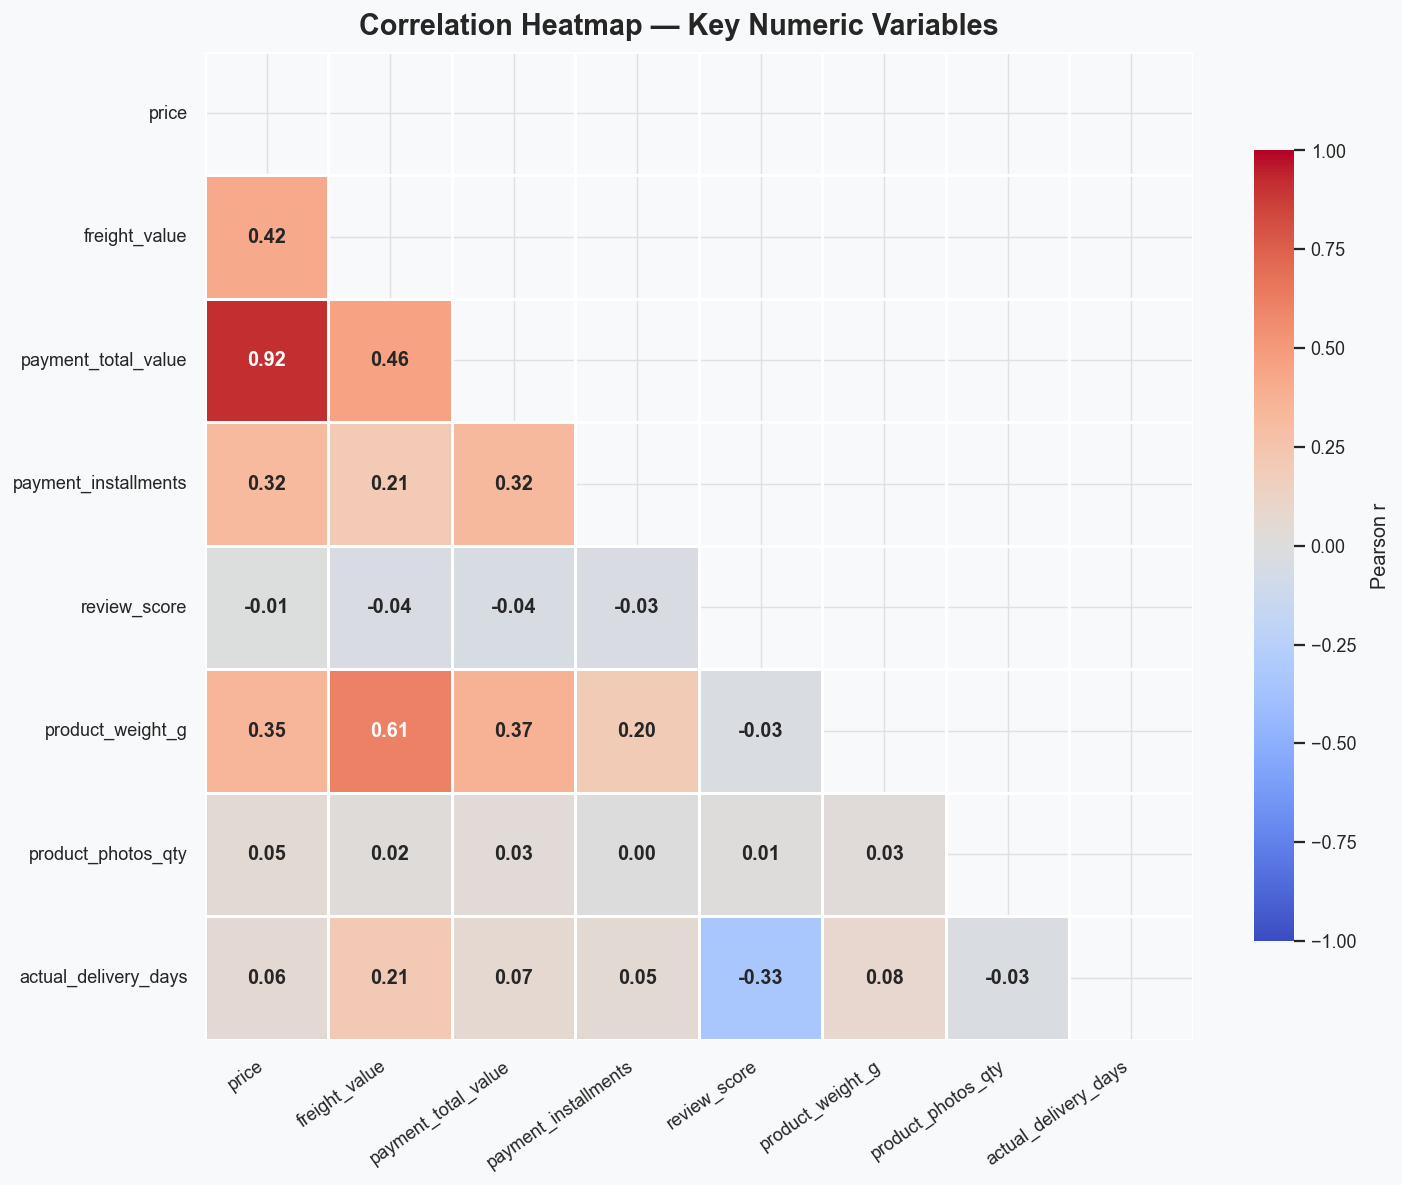

In [12]:
corr_df = delivered.copy().rename(columns={"actual_days": "actual_delivery_days"})

corr_cols = ["price", "freight_value", "payment_total_value",
             "payment_installments", "review_score", "product_weight_g",
             "product_photos_qty", "actual_delivery_days"]

corr_df     = corr_df[corr_cols].dropna()
corr_matrix = corr_df.corr()
mask        = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(11, 9))
fig.suptitle("Correlation Heatmap — Key Numeric Variables", fontsize=16, fontweight="bold")

sns.heatmap(
    corr_matrix, mask=mask,
    annot=True, fmt=".2f", annot_kws={"size": 11, "weight": "bold"},
    cmap="coolwarm", center=0, vmin=-1, vmax=1,
    ax=ax, square=True, linewidths=0.8, linecolor="white",
    cbar_kws={"shrink": 0.8, "label": "Pearson r"}
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right", fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

plt.show()


## 11. Seller Performance

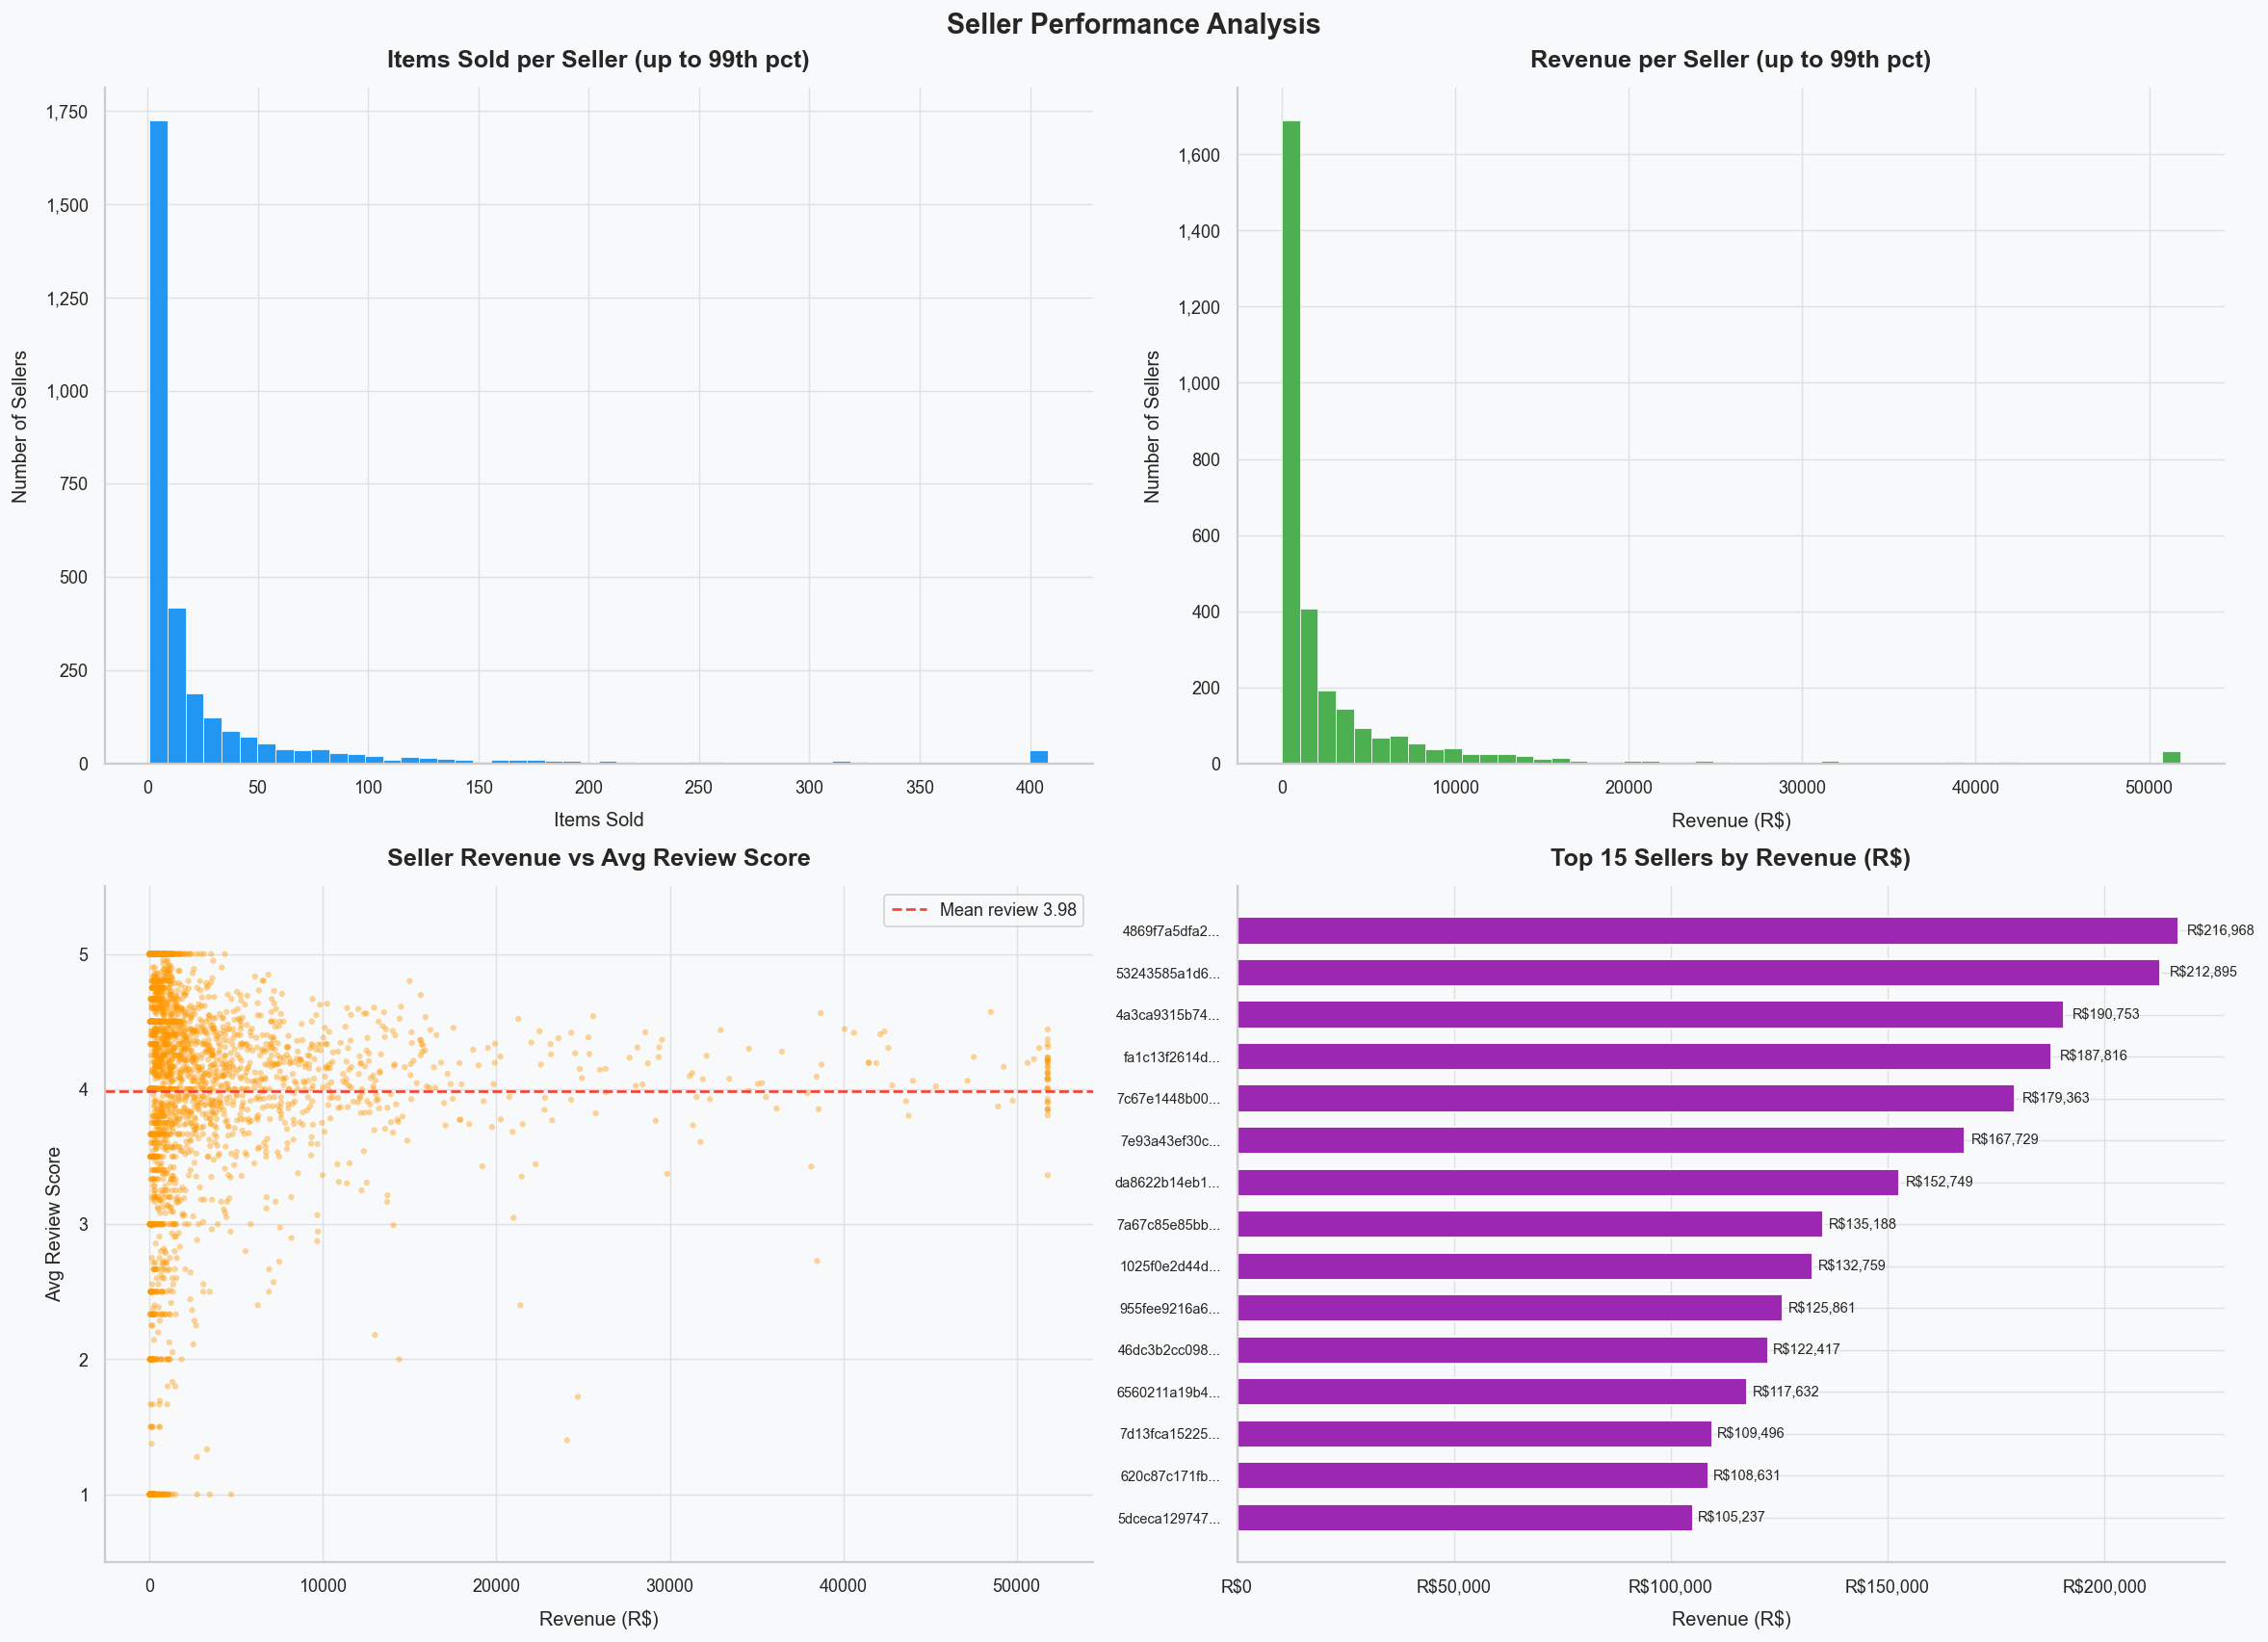

Total sellers: 3,060
Top 10% sellers (306) account for 67.5% of total revenue


In [13]:
seller_stats = df.groupby("seller_id").agg(
    items_sold   =("order_item_id", "count"),
    revenue      =("price", "sum"),
    unique_orders=("order_id", "nunique"),
    avg_price    =("price", "mean"),
    avg_review   =("review_score", "mean"),
    categories   =("product_category_name_english", "nunique")
).reset_index()

top15_sellers = seller_stats.nlargest(15, "revenue").set_index("seller_id")
items_p99     = seller_stats["items_sold"].quantile(0.99)
rev_p99       = seller_stats["revenue"].quantile(0.99)

fig, axes = plt.subplots(2, 2, figsize=(18, 13))
fig.suptitle("Seller Performance Analysis", fontsize=16, fontweight="bold")

# Items sold
axes[0,0].hist(seller_stats["items_sold"].clip(upper=items_p99), bins=50,
               color="#2196F3", edgecolor="white", linewidth=0.4)
axes[0,0].set_title("Items Sold per Seller (up to 99th pct)")
axes[0,0].set_xlabel("Items Sold")
axes[0,0].set_ylabel("Number of Sellers")
axes[0,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Revenue
axes[0,1].hist(seller_stats["revenue"].clip(upper=rev_p99), bins=50,
               color="#4CAF50", edgecolor="white", linewidth=0.4)
axes[0,1].set_title("Revenue per Seller (up to 99th pct)")
axes[0,1].set_xlabel("Revenue (R$)")
axes[0,1].set_ylabel("Number of Sellers")
axes[0,1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Scatter
mean_review = seller_stats["avg_review"].mean()
axes[1,0].scatter(seller_stats["revenue"].clip(upper=rev_p99), seller_stats["avg_review"],
                  alpha=0.4, s=12, color="#FF9800", edgecolors="none")
axes[1,0].axhline(mean_review, color="#F44336", linestyle="--", linewidth=1.5,
                  label=f"Mean review {mean_review:.2f}")
axes[1,0].set_title("Seller Revenue vs Avg Review Score")
axes[1,0].set_xlabel("Revenue (R$)")
axes[1,0].set_ylabel("Avg Review Score")
axes[1,0].set_ylim(0.5, 5.5)
axes[1,0].legend()

# Top 15 revenue
top15_sorted = top15_sellers["revenue"].sort_values()
short_labels = [s[:12]+"..." for s in top15_sorted.index]
bars = axes[1,1].barh(range(len(top15_sorted)), top15_sorted.values,
                      color="#9C27B0", edgecolor="white", height=0.65)
axes[1,1].set_yticks(range(len(top15_sorted)))
axes[1,1].set_yticklabels(short_labels, fontsize=8)
axes[1,1].set_title("Top 15 Sellers by Revenue (R$)")
axes[1,1].set_xlabel("Revenue (R$)")
axes[1,1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R${int(x):,}"))
for bar in bars:
    w = bar.get_width()
    axes[1,1].text(w * 1.01, bar.get_y() + bar.get_height()/2,
                   f"R${int(w):,}", va="center", fontsize=8)

plt.show()

total_sellers = len(seller_stats)
top10pct_n    = max(1, int(total_sellers * 0.10))
top10pct_rev  = seller_stats.nlargest(top10pct_n, "revenue")["revenue"].sum()
pct_of_total  = top10pct_rev / seller_stats["revenue"].sum() * 100
print(f"Total sellers: {total_sellers:,}")
print(f"Top 10% sellers ({top10pct_n:,}) account for {pct_of_total:.1f}% of total revenue")


## 12. Seller Churn Analysis (2017 → 2018)

2017 sellers         : 1,766
Churned (2017→2018)  : 677  (38.3%)
Retained             : 1,089  (61.7%)
New sellers in 2018  : 1,268
Revenue at risk      : R$ 668,879  (11.5% of 2017 revenue)
Median items (churned)   : 3
Median items (retained)  : 12


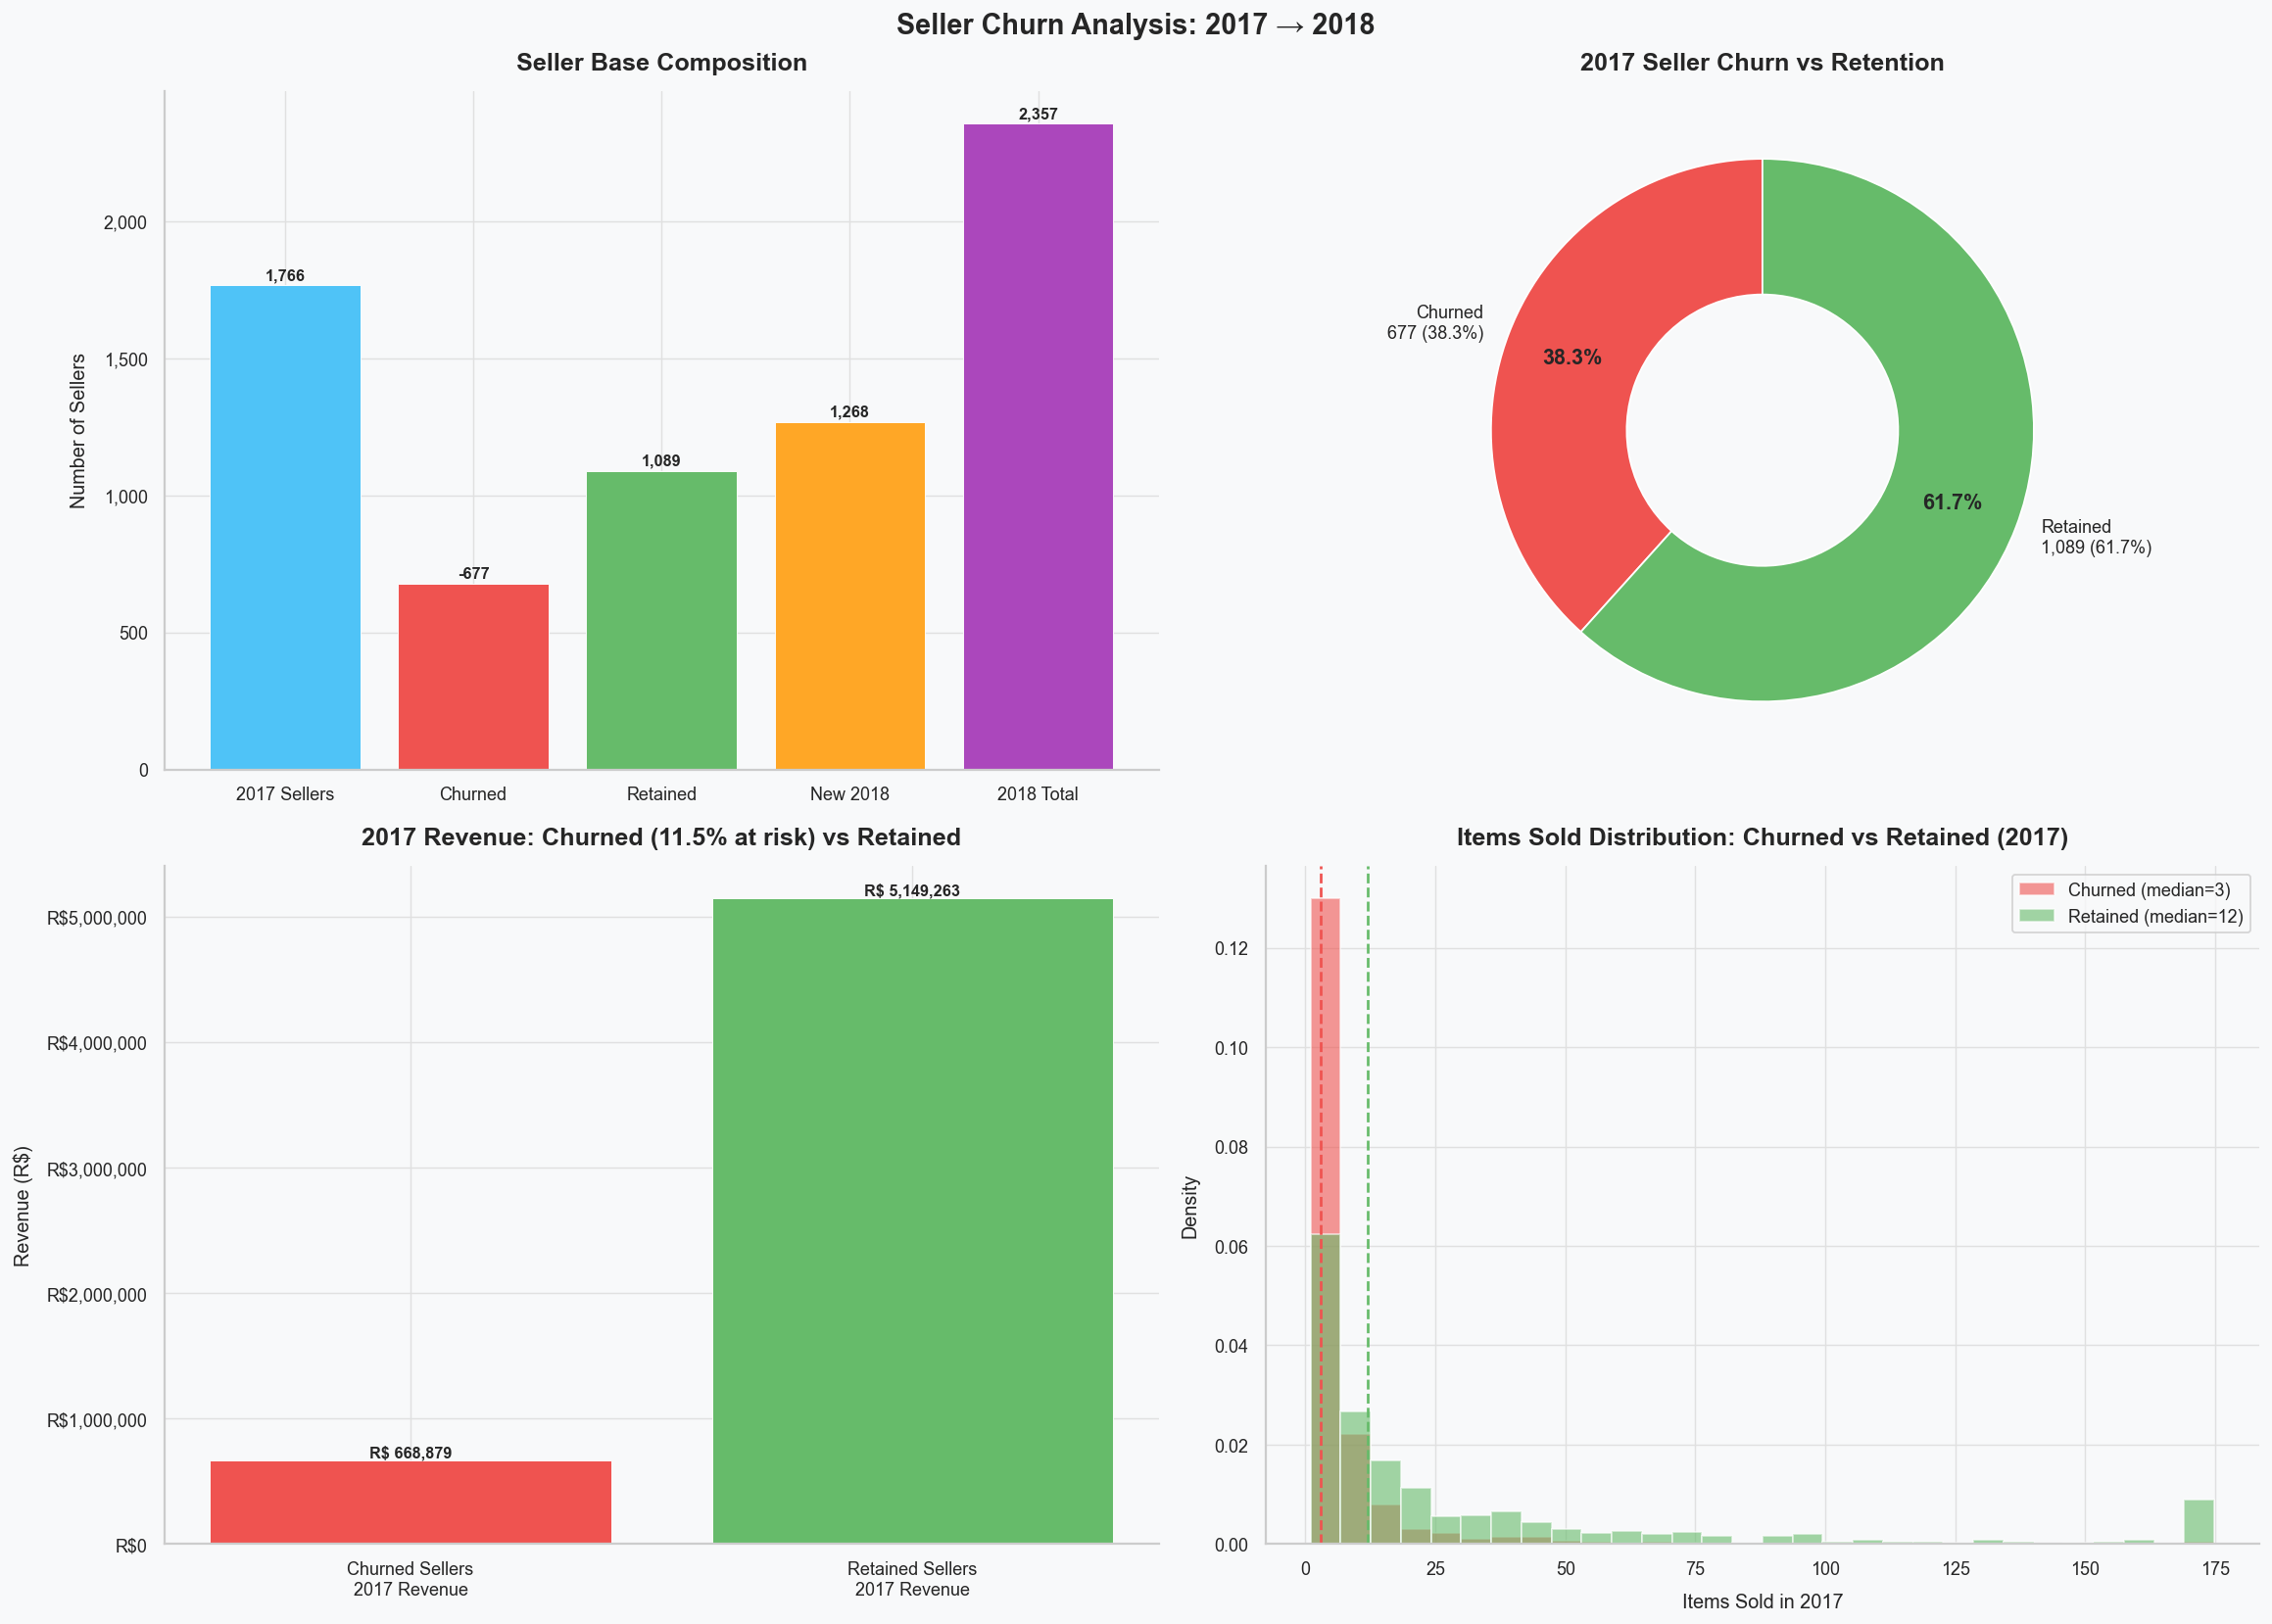

In [14]:
# ── Seller Churn Analysis ────────────────────────────────────────────────────
if 'df' not in dir():
    import pandas as pd, numpy as np, matplotlib.pyplot as plt, matplotlib as mpl
    import matplotlib.ticker as mticker
    import warnings; warnings.filterwarnings('ignore')
    DATE_COLS = ['order_purchase_timestamp','order_approved_at','order_delivered_carrier_date',
                 'order_delivered_customer_date','order_estimated_delivery_date','shipping_limit_date',
                 'review_creation_date','review_answer_timestamp']
    df = pd.read_csv('main_dataset_clean.csv', parse_dates=DATE_COLS)

df['year'] = df['order_purchase_timestamp'].dt.year
sellers_2016 = set(df[df['year'] == 2016]['seller_id'])
sellers_2017 = set(df[df['year'] == 2017]['seller_id'])
sellers_2018 = set(df[df['year'] == 2018]['seller_id'])

# Churn: active in 2017, zero orders in 2018
churned   = sellers_2017 - sellers_2018
retained  = sellers_2017 & sellers_2018
new_2018  = sellers_2018 - sellers_2017
churn_rate = len(churned) / len(sellers_2017) * 100

# Revenue at risk from churned sellers (their 2017 revenue)
sel_2017 = df[df['year'] == 2017].groupby('seller_id')['price'].sum()
rev_churned   = sel_2017[sel_2017.index.isin(churned)].sum()
rev_retained  = sel_2017[sel_2017.index.isin(retained)].sum()
rev_total_2017 = sel_2017.sum()
rev_risk_pct   = rev_churned / rev_total_2017 * 100

# Items sold distribution
items_churned  = df[(df['year']==2017) & (df['seller_id'].isin(churned))].groupby('seller_id').size()
items_retained = df[(df['year']==2017) & (df['seller_id'].isin(retained))].groupby('seller_id').size()

print(f'2017 sellers         : {len(sellers_2017):,}')
print(f'Churned (2017→2018)  : {len(churned):,}  ({churn_rate:.1f}%)')
print(f'Retained             : {len(retained):,}  ({100-churn_rate:.1f}%)')
print(f'New sellers in 2018  : {len(new_2018):,}')
print(f'Revenue at risk      : R$ {rev_churned:,.0f}  ({rev_risk_pct:.1f}% of 2017 revenue)')
print(f'Median items (churned)   : {items_churned.median():.0f}')
print(f'Median items (retained)  : {items_retained.median():.0f}')

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 13))
fig.suptitle('Seller Churn Analysis: 2017 → 2018', fontsize=16, fontweight='bold')

# 1. Seller base waterfall bar
ax = axes[0, 0]
bars_data = [
    ('2017 Sellers', len(sellers_2017), '#4FC3F7'),
    ('Churned',     -len(churned),       '#EF5350'),
    ('Retained',    len(retained),        '#66BB6A'),
    ('New 2018',    len(new_2018),         '#FFA726'),
    ('2018 Total',  len(sellers_2018),    '#AB47BC'),
]
labels = [b[0] for b in bars_data]
values = [abs(b[1]) for b in bars_data]
colors = [b[2] for b in bars_data]
bars = ax.bar(labels, values, color=colors, edgecolor='white', linewidth=0.5)
for bar, val, orig in zip(bars, values, [b[1] for b in bars_data]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f"{orig:+,}" if orig != abs(orig) else f"{orig:,}",
            ha='center', va='bottom', fontweight='bold', fontsize=9)
ax.set_title('Seller Base Composition', fontweight='bold')
ax.set_ylabel('Number of Sellers')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# 2. Churn vs Retention donut
ax2 = axes[0, 1]
donut_vals  = [len(churned), len(retained)]
donut_labs  = [f'Churned\n{len(churned):,} ({churn_rate:.1f}%)',
               f'Retained\n{len(retained):,} ({100-churn_rate:.1f}%)']
donut_cols  = ['#EF5350', '#66BB6A']
wedges, texts, autotexts = ax2.pie(
    donut_vals, labels=donut_labs, colors=donut_cols,
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(width=0.5), pctdistance=0.75
)
for t in autotexts:
    t.set_fontweight('bold')
ax2.set_title('2017 Seller Churn vs Retention', fontweight='bold')

# 3. Revenue: at-risk vs retained
ax3 = axes[1, 0]
rev_bars = ax3.bar(
    ['Churned Sellers\n2017 Revenue', 'Retained Sellers\n2017 Revenue'],
    [rev_churned, rev_retained],
    color=['#EF5350', '#66BB6A'], edgecolor='white', linewidth=0.5
)
for bar, val in zip(rev_bars, [rev_churned, rev_retained]):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
             f'R$ {val:,.0f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
ax3.set_title(f'2017 Revenue: Churned ({rev_risk_pct:.1f}% at risk) vs Retained', fontweight='bold')
ax3.set_ylabel('Revenue (R$)')
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${int(x):,}'))

# 4. Items sold histogram overlay
ax4 = axes[1, 1]
clip_val = max(items_churned.quantile(0.95), items_retained.quantile(0.95))
ax4.hist(items_churned.clip(upper=clip_val), bins=30, alpha=0.6,
         color='#EF5350', label=f'Churned (median={items_churned.median():.0f})', density=True)
ax4.hist(items_retained.clip(upper=clip_val), bins=30, alpha=0.6,
         color='#66BB6A', label=f'Retained (median={items_retained.median():.0f})', density=True)
ax4.axvline(items_churned.median(), color='#EF5350', linestyle='--', linewidth=1.5)
ax4.axvline(items_retained.median(), color='#66BB6A', linestyle='--', linewidth=1.5)
ax4.set_title('Items Sold Distribution: Churned vs Retained (2017)', fontweight='bold')
ax4.set_xlabel('Items Sold in 2017')
ax4.set_ylabel('Density')
ax4.legend()

plt.tight_layout()
plt.show()


## 13. Correlation Heatmap

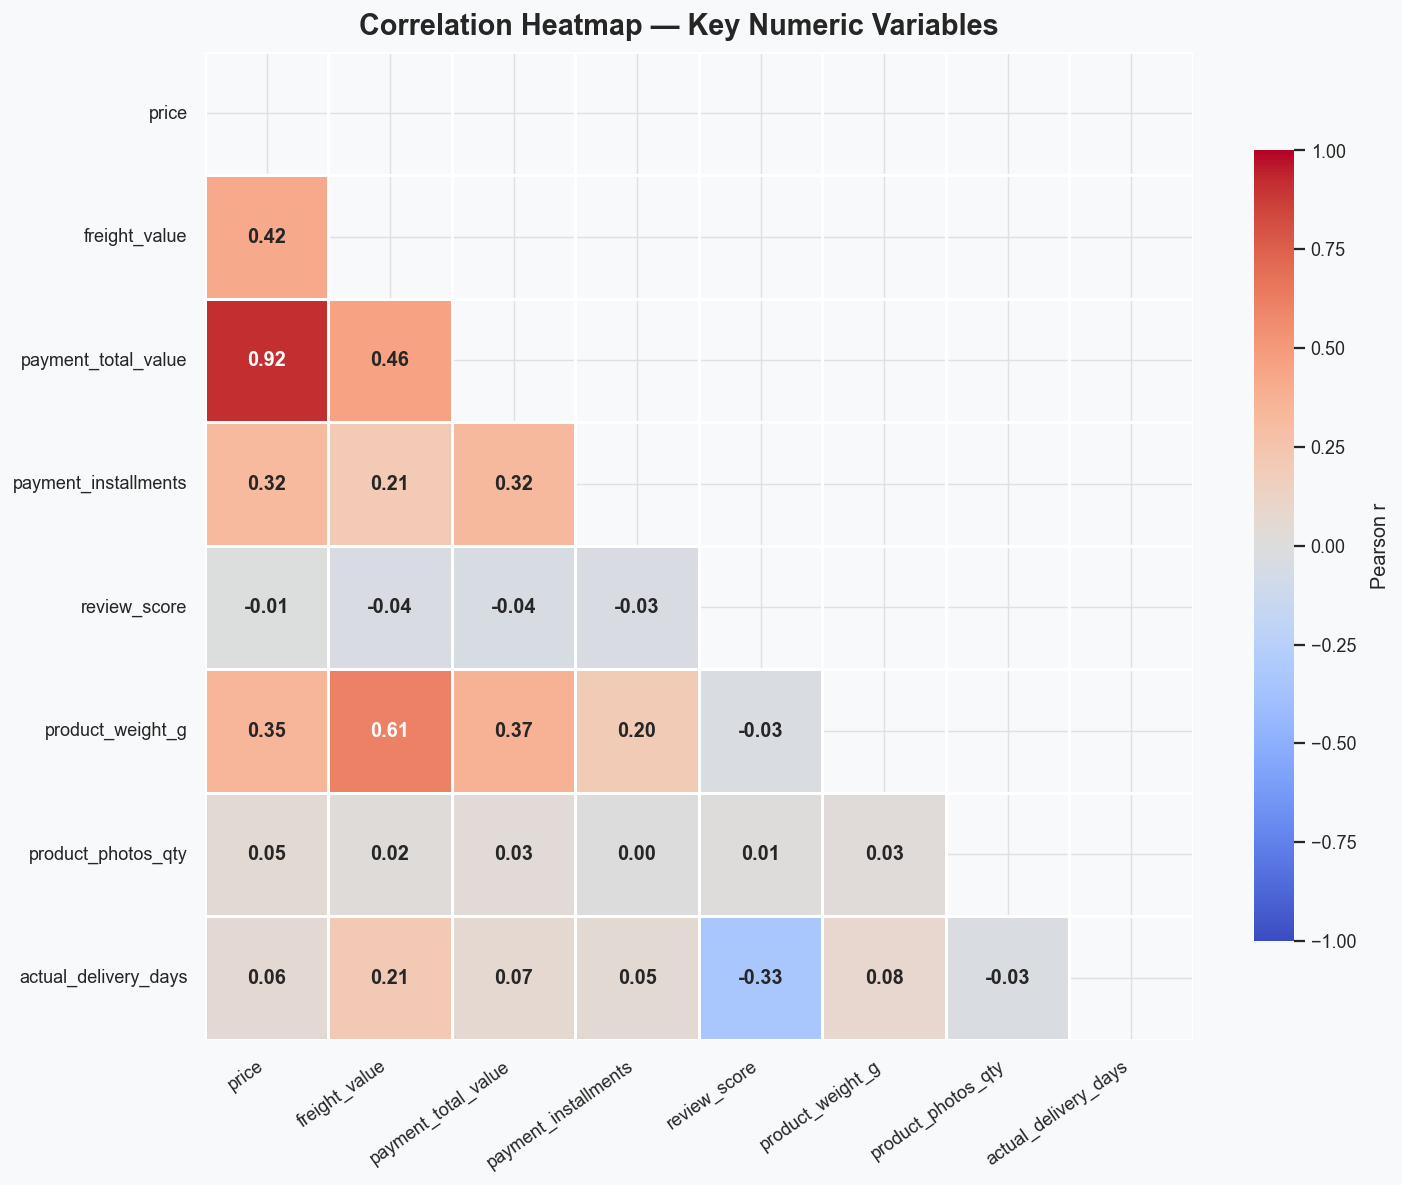

In [15]:
if "df" not in dir():
    import pandas as pd, numpy as np, matplotlib.pyplot as plt, matplotlib as mpl
    import matplotlib.ticker as mticker, matplotlib.colors as mcolors, matplotlib.cm as cm
    import warnings; warnings.filterwarnings("ignore")
    DATE_COLS = ["order_purchase_timestamp","order_approved_at","order_delivered_carrier_date",
                 "order_delivered_customer_date","order_estimated_delivery_date","shipping_limit_date",
                 "review_creation_date","review_answer_timestamp"]
    df = pd.read_csv("main_dataset_clean.csv", parse_dates=DATE_COLS)
    ANNOT_FS = 9
    LABEL_FS = 11

if "delivered" not in dir():
    delivered = df[df["order_status"] == "delivered"].drop_duplicates("order_id").copy()
    delivered = delivered.dropna(subset=["order_delivered_customer_date",
                                         "order_purchase_timestamp",
                                         "order_estimated_delivery_date"])
    delivered["actual_days"]    = (delivered["order_delivered_customer_date"] - delivered["order_purchase_timestamp"]).dt.days
    delivered["estimated_days"] = (delivered["order_estimated_delivery_date"] - delivered["order_purchase_timestamp"]).dt.days
    delivered["on_time"]        = (delivered["estimated_days"] - delivered["actual_days"]) >= 0

corr_df = delivered.copy().rename(columns={"actual_days": "actual_delivery_days"})

corr_cols = ["price", "freight_value", "payment_total_value",
             "payment_installments", "review_score", "product_weight_g",
             "product_photos_qty", "actual_delivery_days"]

corr_df     = corr_df[corr_cols].dropna()
corr_matrix = corr_df.corr()
mask        = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(11, 9))
fig.suptitle("Correlation Heatmap — Key Numeric Variables", fontsize=16, fontweight="bold")

sns.heatmap(
    corr_matrix, mask=mask,
    annot=True, fmt=".2f", annot_kws={"size": 11, "weight": "bold"},
    cmap="coolwarm", center=0, vmin=-1, vmax=1,
    ax=ax, square=True, linewidths=0.8, linecolor="white",
    cbar_kws={"shrink": 0.8, "label": "Pearson r"}
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right", fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

plt.show()


## 14. Key Insights Summary

In [16]:
if "df" not in dir():
    import pandas as pd, numpy as np, matplotlib.pyplot as plt, matplotlib as mpl
    import matplotlib.ticker as mticker, matplotlib.colors as mcolors, matplotlib.cm as cm
    import warnings; warnings.filterwarnings("ignore")
    DATE_COLS = ["order_purchase_timestamp","order_approved_at","order_delivered_carrier_date",
                 "order_delivered_customer_date","order_estimated_delivery_date","shipping_limit_date",
                 "review_creation_date","review_answer_timestamp"]
    df = pd.read_csv("main_dataset_clean.csv", parse_dates=DATE_COLS)
    ANNOT_FS = 9
    LABEL_FS = 11

if "delivered" not in dir():
    delivered = df[df["order_status"] == "delivered"].drop_duplicates("order_id").copy()
    delivered = delivered.dropna(subset=["order_delivered_customer_date",
                                         "order_purchase_timestamp",
                                         "order_estimated_delivery_date"])
    delivered["actual_days"]    = (delivered["order_delivered_customer_date"] - delivered["order_purchase_timestamp"]).dt.days
    delivered["estimated_days"] = (delivered["order_estimated_delivery_date"] - delivered["order_purchase_timestamp"]).dt.days
    delivered["on_time"]        = (delivered["estimated_days"] - delivered["actual_days"]) >= 0

if "orders_pay" not in dir():
    orders_pay = df.drop_duplicates("order_id")[["order_id", "payment_type",
                                                  "payment_installments", "payment_total_value"]]

if "freight_pct" not in df.columns:
    df["freight_pct"] = df["freight_value"] / (df["price"] + df["freight_value"]) * 100

total_orders_final = df['order_id'].nunique()
total_revenue_final = df['price'].sum()
avg_review_final = df['review_score'].mean()
on_time_pct = delivered['on_time'].mean() * 100

customer_order_counts = df.drop_duplicates('order_id').groupby('customer_unique_id').size()
repeat_customer_pct = (customer_order_counts > 1).mean() * 100

top_category = df.groupby('product_category_name_english')['price'].sum().idxmax()
top_state = df.drop_duplicates('order_id')['customer_state'].value_counts().idxmax()

cc_pct = (orders_pay['payment_type'] == 'credit_card').mean() * 100
avg_delivery_final = delivered['actual_days'].mean()
avg_freight_pct_final = df['freight_pct'].mean()

summary = {
    'Total Orders': f'{total_orders_final:,}',
    'Total Revenue': f'R$ {total_revenue_final:,.2f}',
    'Avg Review Score': f'{avg_review_final:.2f} / 5',
    'On-Time Delivery %': f'{on_time_pct:.1f}%',
    'Repeat Customer %': f'{repeat_customer_pct:.1f}%',
    'Top Revenue Category': top_category,
    'Top State by Orders': top_state,
    'Credit Card Usage %': f'{cc_pct:.1f}%',
    'Avg Delivery Time': f'{avg_delivery_final:.1f} days',
    'Avg Freight %': f'{avg_freight_pct_final:.1f}%'
}

print('=' * 50)
print('KEY INSIGHTS SUMMARY - Brazil Olist E-Commerce')
print('=' * 50)
for k, v in summary.items():
    print(f'{k:<28}: {v}')
print('=' * 50)

KEY INSIGHTS SUMMARY - Brazil Olist E-Commerce
Total Orders                : 93,369
Total Revenue               : R$ 12,862,961.28
Avg Review Score            : 4.04 / 5
On-Time Delivery %          : 92.4%
Repeat Customer %           : 2.9%
Top Revenue Category        : health_beauty
Top State by Orders         : SP
Credit Card Usage %         : 75.8%
Avg Delivery Time           : 12.1 days
Avg Freight %               : 21.3%
